# SINGLE CELL CELLRANGER ANALYSIS - PART I

### Created by: Holly Vose
### Last Modified: 7/16/2026
This notebook is intended for the analysis of STAR/10X Genomics aligned and outputted single cell RNA sequencing data. 

Much of this notebook was also taken from the scanpy basic tutorial on single-cell RNA sequencing processing: https://scanpy.readthedocs.io/en/latest/tutorials/basics/clustering.html

In [2]:
#STEP 1: IMPORTS
#Load this first

import warnings
import scanpy as sc
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import doubletdetection
import soupx
import harmonypy as hm
import decoupler
import scvi
from IPython.display import clear_output 
import re
import os

warnings.filterwarnings('ignore')

/projects/hvose@xsede.org/software/anaconda/envs/jupyter_scrna/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## PRE-PREPROCESSING
In order to properly analyze the data, it needs to be loaded and processed accordingly.

### AnnData Objects
AnnData objects are specialized data structures built to handle high-density information and data, in the form of **Ann**otated **Data** Matrices.
These data matrices can hold a lot of information about the cells.

In an AnnData object, there are three major axes: **observations**, **variables**, and **unstructured**.

- **Observations** are the literal cell barcodes. These are the rows of the matrix, where each row represents a specific cell barcode.
- **Variables** are the genes and other metrics that describe the cell. This includes (but is not limited to) gene expression levels, QC metrics, and annotations such as cell type.
- **Unstructured** is not necessarily associated with either observations or variables, but contain important information about the data (this can include graph colors, dotplots, and other nonspecific analyses)

Steps 2 and 3 will ensure that:

a. Our data is loaded properly \
b. The observations (barcodes) and variables (genes) are unique (if there are repeats, flags are added to the end of the barcode to make them unique) \
c. All of our samples are loaded into a single AnnData object.

Additionally, you can add extra columns here to add information that is not contained in the original data (such as infection type, sample type, etc...)

In [2]:
#This cell corresponds to the first of the fixed scRNA experiments (treatment, 2/9/2026)

experiment = "fiber"

filtered_samples = {"sample_1":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample1/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_2":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample2/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_3":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample3/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_4":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample4/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_5":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample5/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_6":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample6/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_7":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample7/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_8":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample8/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_9":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample9/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_10":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample10/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_11":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample11/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_12":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample12/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_13":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample13/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_14":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample14/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_15":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample15/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_16":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample16/count/sample_filtered_feature_bc_matrix.h5"}

raw_samples = {"sample_1":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample1/count/sample_raw_feature_bc_matrix.h5",
                   "sample_2":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample2/count/sample_raw_feature_bc_matrix.h5",
                   "sample_3":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample3/count/sample_raw_feature_bc_matrix.h5",
                   "sample_4":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample4/count/sample_raw_feature_bc_matrix.h5",
                   "sample_5":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample5/count/sample_raw_feature_bc_matrix.h5",
                   "sample_6":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample6/count/sample_raw_feature_bc_matrix.h5",
                   "sample_7":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample7/count/sample_raw_feature_bc_matrix.h5",
                   "sample_8":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample8/count/sample_raw_feature_bc_matrix.h5",
                   "sample_9":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample9/count/sample_raw_feature_bc_matrix.h5",
                   "sample_10":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample10/count/sample_raw_feature_bc_matrix.h5",
                   "sample_11":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample11/count/sample_raw_feature_bc_matrix.h5",
                   "sample_12":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample12/count/sample_raw_feature_bc_matrix.h5",
                   "sample_13":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample13/count/sample_raw_feature_bc_matrix.h5",
                   "sample_14":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample14/count/sample_raw_feature_bc_matrix.h5",
                   "sample_15":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample15/count/sample_raw_feature_bc_matrix.h5",
                   "sample_16":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/Fixed_02092026_SRK/fixed_scRNA_20260209/outs/per_sample_outs/sample16/count/sample_raw_feature_bc_matrix.h5"}

In [ ]:
#This cell corresponds to the second of the fixed scRNA experiments (viral genetics, 3/11/2026)
experiment = "dHE"

filtered_samples = {"sample_1":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample1/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_2":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample2/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_3":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample3/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_4":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample4/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_5":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample5/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_6":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample6/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_7":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample7/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_8":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample8/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_9":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample9/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_10":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample10/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_11":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample11/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_12":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample12/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_13":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample13/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_14":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample14/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_15":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample15/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_16":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample16/count/sample_filtered_feature_bc_matrix.h5"}

raw_samples = {"sample_1":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample1/count/sample_raw_feature_bc_matrix.h5",
                   "sample_2":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample2/count/sample_raw_feature_bc_matrix.h5",
                   "sample_3":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample3/count/sample_raw_feature_bc_matrix.h5",
                   "sample_4":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample4/count/sample_raw_feature_bc_matrix.h5",
                   "sample_5":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample5/count/sample_raw_feature_bc_matrix.h5",
                   "sample_6":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample6/count/sample_raw_feature_bc_matrix.h5",
                   "sample_7":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample7/count/sample_raw_feature_bc_matrix.h5",
                   "sample_8":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample8/count/sample_raw_feature_bc_matrix.h5",
                   "sample_9":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample9/count/sample_raw_feature_bc_matrix.h5",
                   "sample_10":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample10/count/sample_raw_feature_bc_matrix.h5",
                   "sample_11":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample11/count/sample_raw_feature_bc_matrix.h5",
                   "sample_12":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample12/count/sample_raw_feature_bc_matrix.h5",
                   "sample_13":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample13/count/sample_raw_feature_bc_matrix.h5",
                   "sample_14":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample14/count/sample_raw_feature_bc_matrix.h5",
                   "sample_15":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample15/count/sample_raw_feature_bc_matrix.h5",
                   "sample_16":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/20260311_scRNA_fixed_dHE/outs_fixed_scRNA_20260331/per_sample_outs/sample16/count/sample_raw_feature_bc_matrix.h5"}

In [ ]:
filtered_samples = {"all_samples":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/multi/count/raw_feature_bc_matrix.h5"}

In [ ]:
os.environ["SLURM_NTASKS_PER_NODE"] = os.environ.get("SLURM_NTASKS")

In [ ]:
!echo $SLURM_NTASKS_PER_NODE

In [ ]:
os.environ.get("SLURM_NTASKS")

In [3]:
#STEP 3: GENERATE ANNDATA OBJECT WITH SAMPLES
#For each item in our dictionary, we want to read in the info, make the cells unique, and then combine them into a single object
#Additionally, we are going to add an "infection type" (i_type) column that specifies the infection type based on the loaded sample.
#note: scvi-tools on CPU can take up to 6.5 hrs to properly finish!!!
adatas = {}
adatas_raw = {}

for sample_id, filename in filtered_samples.items():
    sample_adata = sc.read_10x_h5(filename)
    #sample_adata = sc.read_10x_mtx(filename,compressed=True)
    sample_adata.var_names_make_unique()
    sample_adata.var["mt"] = sample_adata.var_names.str.startswith("mt-")
    sc.pp.calculate_qc_metrics(
        sample_adata, qc_vars=["mt"], inplace=True, log1p=True
    )
    sample_adata_mid_filter = sample_adata[sample_adata.obs['pct_counts_mt']<5]
    print(f"finished mt removal for sample id {sample_id}")
    sc.pp.filter_genes(sample_adata_mid_filter,min_cells=10)
    sc.pp.filter_cells(sample_adata_mid_filter,min_genes=30)
    #sc.pp.highly_variable_genes(sample_adata_mid_filter,n_top_genes=2000, subset=True, flavor="seurat_v3")
    print(f"new adata shape is {sample_adata_mid_filter.shape}\nNow calculating scrublets for {sample_id}")
    sc.pp.scrublet(sample_adata_mid_filter)
    sc.pp.pca(sample_adata_mid_filter)
    sc.pp.neighbors(sample_adata_mid_filter)
    sc.tl.umap(sample_adata_mid_filter)

    # scvi.model.SCVI.setup_anndata(sample_adata_mid_filter)
    # vae = scvi.model.SCVI(sample_adata_mid_filter)
    # vae.train()

    # solo = scvi.external.SOLO.from_scvi_model(vae)
    # solo.train()

    # df_doublet = solo.predict()
    # df_doublet['prediction'] = solo.predict(soft=False)

    #takes out the extra annotations added by solo
    # df_doublet.index = df_doublet.index.map(lambda x: x[:-2])

    #creates a difference category for adjusting doublet values based on gradients
    # df_doublet['difference'] = df_doublet.doublet - df_doublet.singlet

    # doublets = df_doublet[(df_doublet['prediction'] == 'doublet') & (df_doublet.difference > 1)]

    # sample_adata.obs['doublet_predict'] = sample_adata.obs.index.isin(doublets.index)

    # sample_adata = sample_adata[~sample_adata.obs.doublet_predict]
    
    adatas[sample_id] = sample_adata_mid_filter
    print(sample_adata)
    print(f"finished processing for sample {sample_id}")

    # print(f"finished processing for sample id {sample_id}")


finished mt removal for sample id sample_1
new adata shape is (9437, 13848)
Now calculating scrublets for sample_1
AnnData object with n_obs × n_vars = 9916 × 19059
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
finished processing for sample sample_1
finished mt removal for sample id sample_2
new adata shape is (7832, 13491)
Now calculating scrublets for sample_2
AnnData object with n_obs × n_vars = 8117 × 19059
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_

In [5]:
#COLOR DEFINITIONS
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

In [ ]:
# for sample_id, filename in raw_samples.items():
#     sample_adata = sc.read_10x_h5(filename)
#     #sample_adata = sc.read_10x_mtx(filename,compressed=True)
#     sample_adata.var_names_make_unique()
#     adatas_raw[sample_id] = sample_adata

# adata_raw = ad.concat(adatas_raw, label="sample")
# adata_raw.obs_names_make_unique()

sample_adata = sc.read_10x_h5(raw_samples["sample_3"])
sample_adata.var_names_make_unique()
sample_adata.obs_names_make_unique()


In [ ]:
%matplotlib inline
#plotting barcode ranks

# 1. Get counts per cell (takes the sum of all cells x genes for a read, then returns as a 1D array)
counts_per_cell = np.array(sample_adata.X.sum(axis=1)).flatten()

# 2. Sort counts highest to lowest
sorted_counts = np.sort(counts_per_cell)[::-1]

# 3. Generate the Barcode Rank Plot
fig, ax = plt.subplots(figsize=(6, 5))

# 4. Plot on a log-log scale
ax.loglog(sorted_counts, color="black", linewidth=2)

ax.set_title("Barcode Rank Plot")
ax.set_xlabel("Barcode Rank")
ax.set_ylabel("Total UMI Count")

# 5. Add gridlines
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
# Create SoupChannel
soup_channel = soupx.SoupChannel(
    tod=adata_raw.X.T.tocsr(),    # table of droplets: raw counts (genes × droplets)
    toc=adata.X.T.tocsr(), # table of counts: filtered counts (genes × cells)
    metaData=pd.DataFrame(index=adata.obs_names)
)

# Add clustering information (essential for good results)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5)
soup_channel.setClusters(adata.obs['leiden'].values)

# Estimate and remove contamination
soup_channel = soupx.autoEstCont(soup_channel, soup_quantile=0.9, verbose=True)
corrected_matrix = soupx.adjustCounts(soup_channel)

# Replace counts in AnnData object
adata_corrected = adata.copy()
adata_corrected.X = corrected_matrix.T  # Convert back to cells × genes


## PREPROCESSING
If `adata.obs` was printed, we should see three columns: one with the cell barcodes, one with the **sample** name, and one with the **i_type**.
We can now move on to regular preprocessing.

### QUALITY CONTROL

Depending on the goal of the analysis, it may be helpful to generate quality control metrics on the dataset. The built-in `sc.pp.calculate_qc_metrics` function will automatically generate helpful metrics, including:

- Number of genes by count
- Total number of gene counts
- Percentage of specific gene counts

By providing what to analyze, we can get a broad, initial look at what gene expression levels look like. You can either specify a single gene, or a family of genes based on their naming conventions (i.e. all mitochondrial genes have the same naming scheme: MT- for human, mt- for mouse). If making new columns for multiple genes, you can call the QC function on everything at once by putting multiple column names in the `qc_vars` parameter.

In [ ]:
#Optional: Check to see if ribosomal filtering is necessary
adata.var_names[adata.var_names.str.startswith("Rpl")].tolist()

In [ ]:
#STEP 4: Generate QC metrics for our "MHV-Y" gene and our mitochondrial counts
adata.var["mt"] = adata.var_names.str.startswith("mt-")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, log1p=True
)

In [ ]:
#STEP 4.5: Visualizing the generated QC metrics. Note that if other columns are specified, their specific
#counts will be labeled as pct_counts_[column name]
%matplotlib inline
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts","pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

#sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mhvy")
ax = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts",color="pct_counts_mt",show=False)
ax.axhline(y=100)
ax.axvline(x=100)
ax.set_xlim(-5,10000)
ax.set_ylim(-5,5000)

### GETTING A FILTERED OBJECT
When attempting to filter for cells with specific gene expression, it can be useful to return an AnnData object of all the cells associated with a positive gene expression.
To do this, we can assign a new variable of all the cell barcode names where our gene counts are greater than 0. Conversely, if we want to filter out cells with too many gene counts 
(i.e. cells with very high mitochondrial gene counts are often associated with cell stress), we can look at our violin plot to determine an optimal level of filtering.

The main takeaway here is that quality control is an active process, and downstream analysis may require revisiting prior thresholds to properly fine tune the data. 

In [ ]:
#STEP 5: Filtering for just MHV-Y positive barcodes (or getting rid of cells with too high of a mitochondrial count)
adata_mid_filter = adata[adata.obs['pct_counts_mt']<5]

#If just cell barcodes are desired, you can add .obs_names to the end of the above statement.

#For context in the next section, we will print the dimensions of our current object.
adata_mid_filter.shape

In [ ]:
#STEP 4.5: Visualizing the generated QC metrics. Note that if other columns are specified, their specific
#counts will be labeled as pct_counts_[column name]
%matplotlib inline
sc.pl.violin(
    adata_mid_filter,
    ["n_genes_by_counts", "total_counts","pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

#sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mhvy")
ax = sc.pl.scatter(adata_mid_filter, "total_counts", "n_genes_by_counts",color="pct_counts_mt",show=False)
ax.axhline(y=100)
ax.axvline(x=100)
ax.set_xlim(-5,10000)
ax.set_ylim(-5,5000)

### KEEPING 'VALID' CELLS
The next three steps relate to how we determine which cells are biologically relevant for analysis. Using `adata_mid_filter.shape` we can see how many cells/genes are filtered out as a result of our next steps.

#### CELL FILTERING
First, we only want to keep cells that express at least one gene. By using `sc.pp.filter_cells` with the parameter `min_genes=1`, we automatically throw away any cell barcodes associated with no gene expression.

**How does a cell end up with no gene expression?** Typically as a combination of "biological" zeros and "technical" zeros. Biological zeros represent a lack of gene expression because these genes are not expressed in this cell type. Technical zeros are an issue related to sequencing where the sequencer does not detect the minimal amount of mRNA needed for capture, or due to sampling error of the cells. 

In [ ]:
#STEP 6: Filter out cells with less than 1 gene expressed, and display the dimensions of our AnnData object
sc.pp.filter_cells(adata_mid_filter, min_genes=30)
adata_mid_filter.shape

#### GENE FILTERING
Next, we consider that every possible gene contained in our reference genome are not all expressed within our dataset. As such, we can keep genes that are expressed in at least one cell using `sc.pp.filter_genes` with the setting `min_cells=1`.

In [ ]:
#STEP 7: Filter out genes that are expressed in no cells
sc.pp.filter_genes(adata_mid_filter, min_cells=5)
adata_mid_filter.shape

#### COUNT FILTERING
Finally, we would like to remove cells that have exceptionally low (ambient RNAs in empty cells) or high (multiplet) counts.

In [ ]:
sc.pp.filter_cells(adata_mid_filter, min_counts=500)
print(adata_mid_filter.shape)
sc.pp.filter_cells(adata_mid_filter, max_counts=25000)
print(adata_mid_filter.shape)

#### DOUBLET DETECTION
In scRNA-seq, **doublets** are cells that contain the information and expression levels from two cells, but are displayed as a single cell. These come from sampling and sequencing errors, but can be computationally detected through a variety of methods. Scanpy has a built-in function called `scrublet` that detects potential doublets and saves their information for later use. 

***NOTE:*** This can take a while, as it profiles every cell in the population and computationally evaluates every single expression profile to determine doublet potential. 

In [ ]:
#STEP 8: Search for cells that are likely doublets. This can take a while!
#The batch_key is an optional parameter to differentiate between sampling batches, should not affect final result.
sc.pp.scrublet(adata_mid_filter, batch_key="sample")

## SUBSETTING FOR SUB-CLUSTERS

Sometimes, it may be beneficial to get a subset of a cluster that has specific activity. The example below gets all cells that have CD3+ activity and creates a new object with just those cells. For the purpose of re-clustering, it is ideal to pull this information BEFORE going through normalization. You may need to come back here after you do some initial clustering, depending on what needs to be pulled. Though the example below assumes we want every cell in the dataset with CD3+ activity, it may be desired to provide a list of cell barcodes to pull. This may be helpful when trying to pull a subset from a specific leiden cluster (because we have not clustered at this step yet, in the interest of preserving the original data.)

In [ ]:
#get subset of only cells with Cd3+ activity
cd3 = adata_mid_filter[:,['Cd3e']].X
#ighm = adata_mid_filter[:,['Ighm']].X

if isinstance(cd3, (np.ndarray, list)):
    #for dense arrays or lists
    mask = cd3.flatten() > 0
else:
    # For sparse matrices (e.g., csr_matrix)
    mask = (cd3.toarray().flatten() > 0)

# if isinstance(ighm, (np.ndarray, list)):
#     #for dense arrays or lists
#     i_mask = ighm.flatten() > 0
# else:
#     # For sparse matrices (e.g., csr_matrix)
#     i_mask = (ighm.toarray().flatten() > 0)

adata_subset_view_c = adata_mid_filter[mask, :]
# adata_subset_view_i = adata_mid_filter[i_mask, :]

adata_cd3 = adata_subset_view_c.copy()
# adata_ighm = adata_subset_view_i.copy()



## NORMALIZATION
Now that we have trimmed down our dataset, we want to normalize our data using a count depth scaling and log + 1 normalization scheme. Because scanpy will adjust the values directly, it is helpful to save an extra layer of our count data in case it needs to be referenced later.

In [ ]:
#STEP 10: Normalize and log-scale the data
adata_mid_filter.layers["counts"] = adata_mid_filter.X.copy()
sc.pp.normalize_total(adata_mid_filter)
sc.pp.log1p(adata_mid_filter)

In [ ]:
#STEP 9: Save the count data as its own layer (in case we need to reference it later)
#adata_mid_filter.layers["counts"] = adata_mid_filter.X.copy()
adata_cd3.layers["counts"] = adata_cd3.X.copy()

In [ ]:
#STEP 10: Normalize and log-scale the data (subsets)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## FEATURE SELECTION
Even after our normalization and cell filtering, we still have over 20,000 genes contained in our dataset. For the purpose of our analysis, we want to try and reduce the dimensionality of our dataset to only look at the most descriptive and informative genes in our dataset. We can do this by using the built in `sc.pp.highly_variable_genes` function to determine which genes are the most representative of our dataset, based on the `batch_key` parameter. In this example, we want to find the 2000 most highly variable genes per infection type. 

Similar to the doublet detection, this will take a while as the whole dataset must be analyzed several times. 

If desired, this step can mimic the detection features of Seurat, CellRanger, or Seurat v3 using the `flavor` parameter. Seurat is the default.

In [ ]:
#STEP 11: Calculate the most highly variable genes in our dataset. This can take a while!
sc.pp.highly_variable_genes(adata, n_top_genes=2000,batch_key="condition")
#sc.pp.highly_variable_genes(adata_cd3, n_top_genes=2000)
#sc.pp.highly_variable_genes(adata_ighm, n_top_genes=2000)

In [ ]:
#STEP 11.5: Plot our highly variable genes
#sc.pl.highly_variable_genes(adata_mid_filter)

## CLUSTERING
With our genes properly filtered and taken care of, we can now move on to the bulk of the analysis.

### CLUSTER REPRESENTATION
We can visualize our data by clustering our cells based on their relative log-transformed gene counts. By determining which cells are closely related on a few key dimensions, we can create a 2-dimensional representation of our data. There are two ways to do this:
1. Uniform Manifold Approximation and Projection (UMAP)
2. t-Stochastic Neighbor Embedding (t-SNE)
For an in-depth explanation, read more here: https://alleninstitute.org/resource/what-is-a-umap/

<span style="color:red">**WARNING!** No two **newly** generated UMAPs/t-SNEs will be the same!</span>

Something important to recognize is that the UMAP is a mathematical representation of our data; it is highly sensitive and can be prone to over-describing data. Also, because UMAPs are based on clustering algorithms, no two **newly** generated representations are quite the same (though you can get very close with specific parameters.)

In [ ]:
#STEP 13: Calculate cell clusters based on a specified number of principal components. Based on the PCA from the previous step, if there is a noticeable flattening
%matplotlib inline
sc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
# sc.pp.neighbors(adata_ighm)
# sc.tl.umap(adata_ighm)
#sc.tl.tsne(adata_mid_filter)

In [ ]:
sc.pp.neighbors(adata,n_pcs=11)
sc.tl.umap(adata)
sc.pl.umap(adata, color="sample")

In [ ]:
# Get PCs from the AnnData object
pcs = adata.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, adata.obs, "sample", max_iter_harmony=40)

print("finished harmony")

# Store corrected PCs back in the AnnData object
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr


In [ ]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
#sc.pp.neighbors(adata_mid_filter, n_pcs=12)
sc.tl.umap(adata)
sc.pl.umap(adata, color="sample")

In [ ]:
adata.write_h5ad("dHE_per_samp_doublet_removal_20260617.h5ad")

In [ ]:
del adata
del adata_raw

In [ ]:
#STEP 14 (option 1): Plot the UMAP visualization
sc.pl.umap(
    adata_mid_filter,
    color=["sample","condition"],
    wspace=0.5,
    # Setting a smaller point size to prevent overlap
)

In [ ]:
#STEP 15: Show predicted doublets and which cells have higher doublet scoring (more likely to be doublets)
sc.pl.umap(
    adata,
    color=["doublet_predict"],
    # increase horizontal space between panels
    wspace=0.25,
)

In [ ]:
sc.pp.combat(adata_mid_filter,key='treatment')

In [ ]:
#STEP 14 (option 1): Plot the UMAP visualization
sc.pl.umap(
    adata_epcam,
    color=["treatment"],
    # Setting a smaller point size to prevent overlap
    size=5
)

In [ ]:
#STEP 14 (option 2): Plot the t-SNE visualization
sc.pl.tsne(
    adata_mid_filter,
    color=['i_type'],
    # Setting a smaller point size to prevent overlap
    size=5
)

In [ ]:
#STEP 16: Create a copy of the dataset without cells where predicted_doublet is True
#adata_filtered = adata_mid_filter[~adata_mid_filter.obs['predicted_doublet']].copy()
adata_filtered = adata_mid_filter[adata_mid_filter.obs['doublet_score'] < 0.3].copy()

In [ ]:
sc.pl.umap(adata_filtered, color=["doublet_score","condition"], size=10,)

In [ ]:
#STEP 17: Rerun our PCA to generate new principal components for the clustering
#sc.pp.pca(adata_filtered)
sc.pp.pca(adata_filtered)
sc.pl.pca_variance_ratio(adata_filtered, n_pcs=50, log=True)

In [ ]:
# Get PCs from the AnnData object
pcs = adata_filtered.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, adata_filtered.obs, "sample", max_iter_harmony=20)

print("finished harmony")

# Store corrected PCs back in the AnnData object
adata_filtered.obsm['X_pca_harmony'] = harmony_out.Z_corr
sc.pp.neighbors(adata_filtered, use_rep='X_pca_harmony')
#sc.pp.neighbors(adata_mid_filter, n_pcs=12)
sc.tl.umap(adata_filtered)

In [ ]:
#STEP 18: Rerun all of our clustering on the new, filtered dataset
# sc.pp.neighbors(adata_filtered)
# sc.tl.umap(adata_filtered)
#sc.tl.leiden(adata_filtered, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_filtered, color="condition")
sc.pl.umap(adata_filtered, color="sample")

In [ ]:
#STEP 19: Export the AnnData Object
adata_filtered.write_h5ad("/projects/hvose@xsede.org/adata_filtered_files/20260615_dhe_count_refiltered.h5ad")
#adata_ighm.write_h5ad("adata_ighm_03272026.h5ad")

# **ANALYSIS (i.e. SAVING MY ASS AT 11PM)**

In [3]:
adata = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/20260604_diet_adata_soupx_refiltered.h5ad")

In [91]:

cluster_colors = ["#2E5283",
                  "#004100",
                  "#582B36",
                  "#E2552D",
                  
                  "#C67FAE",
                  "#0D199A",
                  "#98DDDF",
                  
                  "#B623CC",
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  
                  "#F53C9F",
                  "#BAA5FF",
                 "#FCD581"]
#idx 2 = 
#idx 4/5 = "#009499","#E3BD33",
#idx 7/8/9 = "#A6BE47","#D7E8BC","#6D5698",
#idx 11 = "#A00239",

In [6]:
print(adata.obs.dtypes)

sample                         category
treatment                      category
leiden                         category
n_genes_by_counts                 int64
log1p_n_genes_by_counts         float64
total_counts                    float64
log1p_total_counts              float64
pct_counts_in_top_50_genes      float64
pct_counts_in_top_100_genes     float64
pct_counts_in_top_200_genes     float64
pct_counts_in_top_500_genes     float64
total_counts_mt                 float64
log1p_total_counts_mt           float64
pct_counts_mt                   float64
n_genes                           int64
doublet_score                   float64
predicted_doublet                  bool
leiden_res_0.20                category
leiden_res_0.50                category
leiden_res_0.75                category
leiden_res_1.00                category
dtype: object


In [9]:
adata.obs['treatment'] = "3DPI"
for val in range(1,17):
    match val:
            case val if 1<=int(val)<=5:
                adata.obs.loc[adata.obs["sample"] == f"sample_{val}", 'treatment'] = 'no_fiber'
            case val if 6<=int(val)<=10:
                adata.obs.loc[adata.obs["sample"] == f"sample_{val}", 'treatment'] = 'amp'
            case _:
                adata.obs.loc[adata.obs["sample"] == f"sample_{val}", 'treatment'] = '3DPI'

In [4]:
# STEP 3: GENERATE DIFFERENT RESOLUTIONS OF CLUSTERING

for res in [0.2, 0.5, 0.75, 1]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.00"],
    legend_loc="on data",
) 

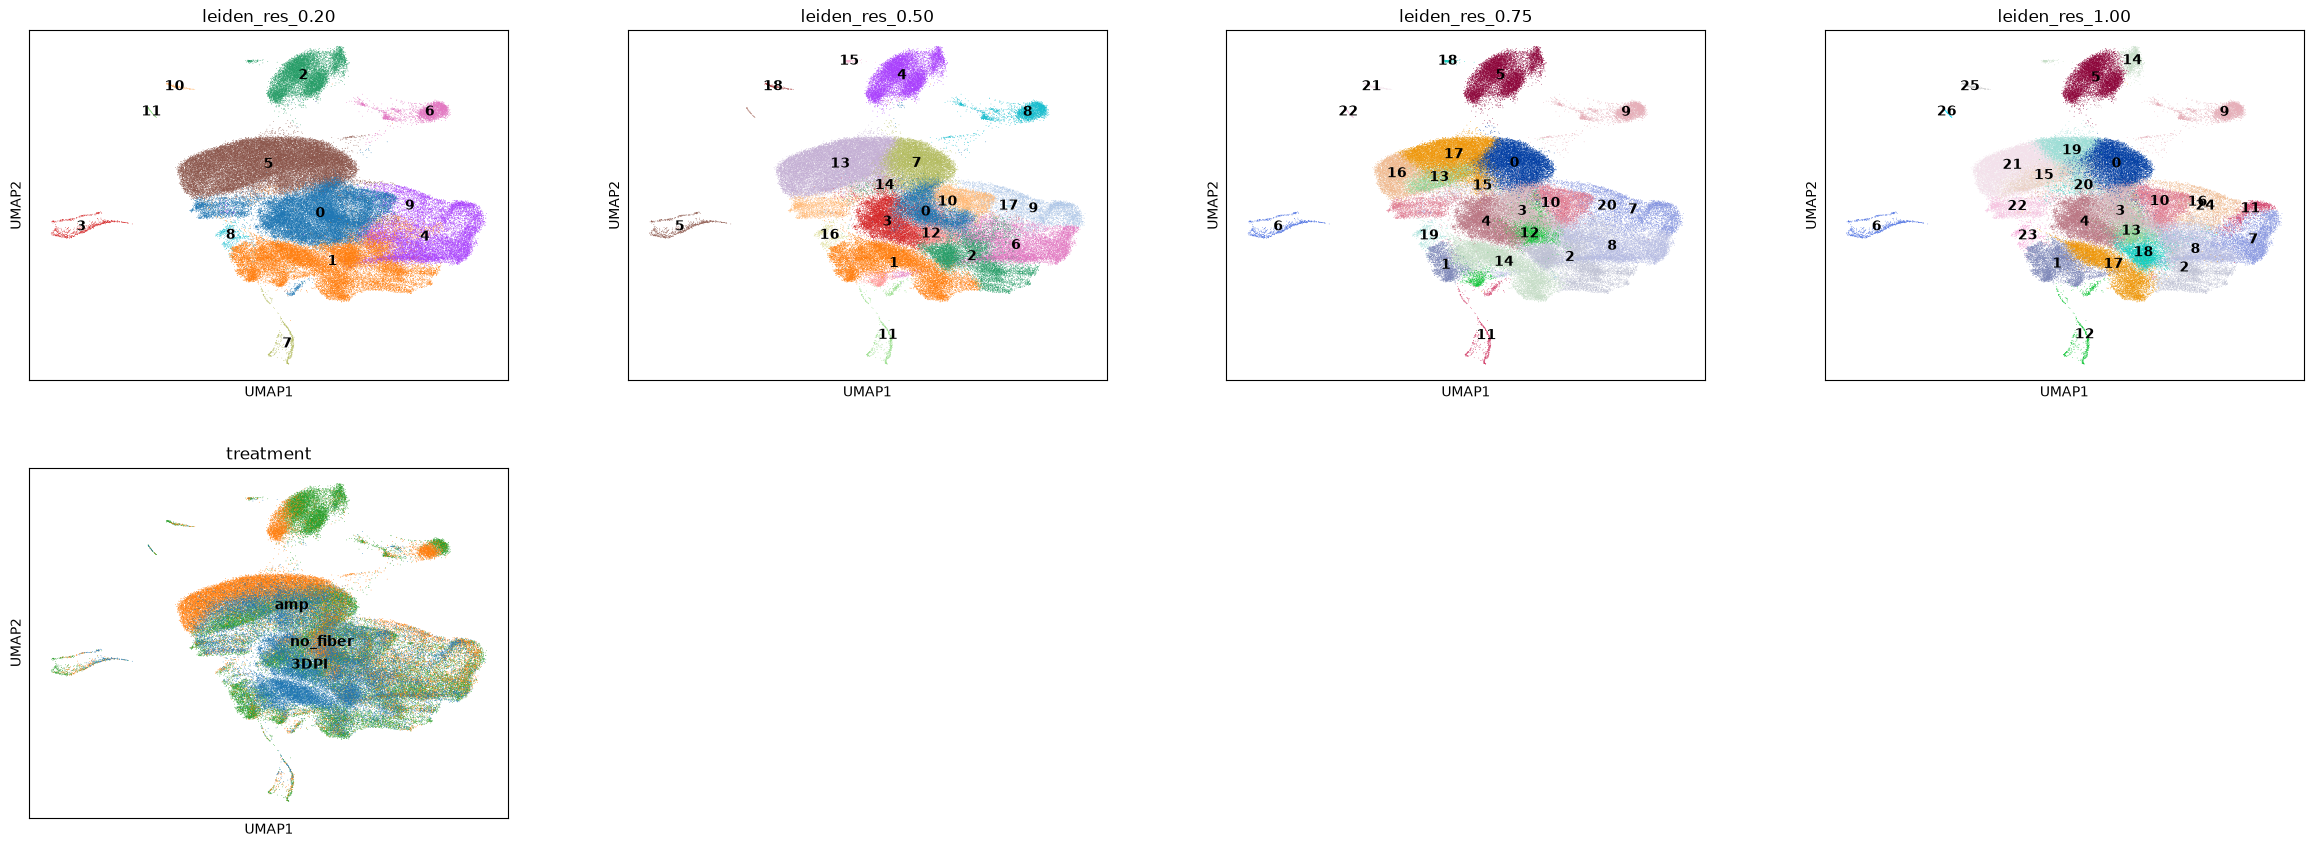

In [10]:
%matplotlib inline

sc.pl.umap(
    adata,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.00","treatment"],
    legend_loc="on data",
) 

In [103]:
markers = ["Hoxb13","Slc26a3", "Npm1", "Aqp4", "Aqp8", "Cyp2c55", "Selenbp1", "Car1", "Cd79a","Chga", "Neurod1", "Muc2", "Tff3", "Spink4", "Zg16", "Ccl6", "Mcpt1","Mcpt2","Sval1", "Lgr5", "Ascl2", "Cd3e", "Cd7", "Clca3b","Mki67", "Top2a", "Ube2c", "Dclk1"]

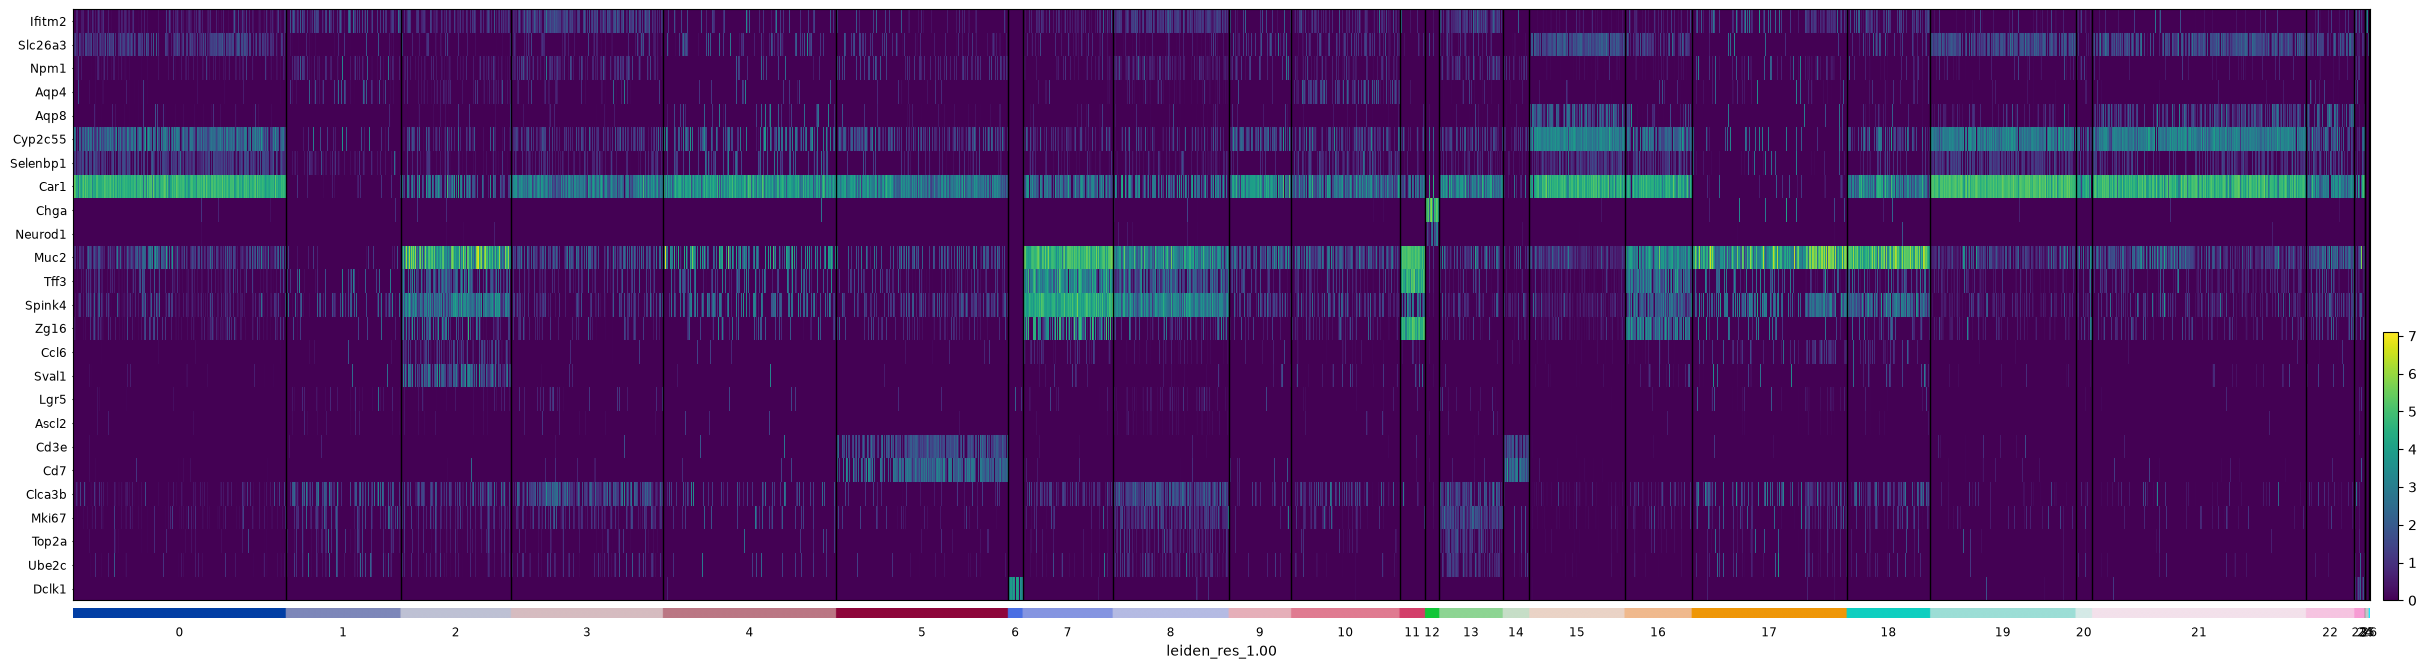

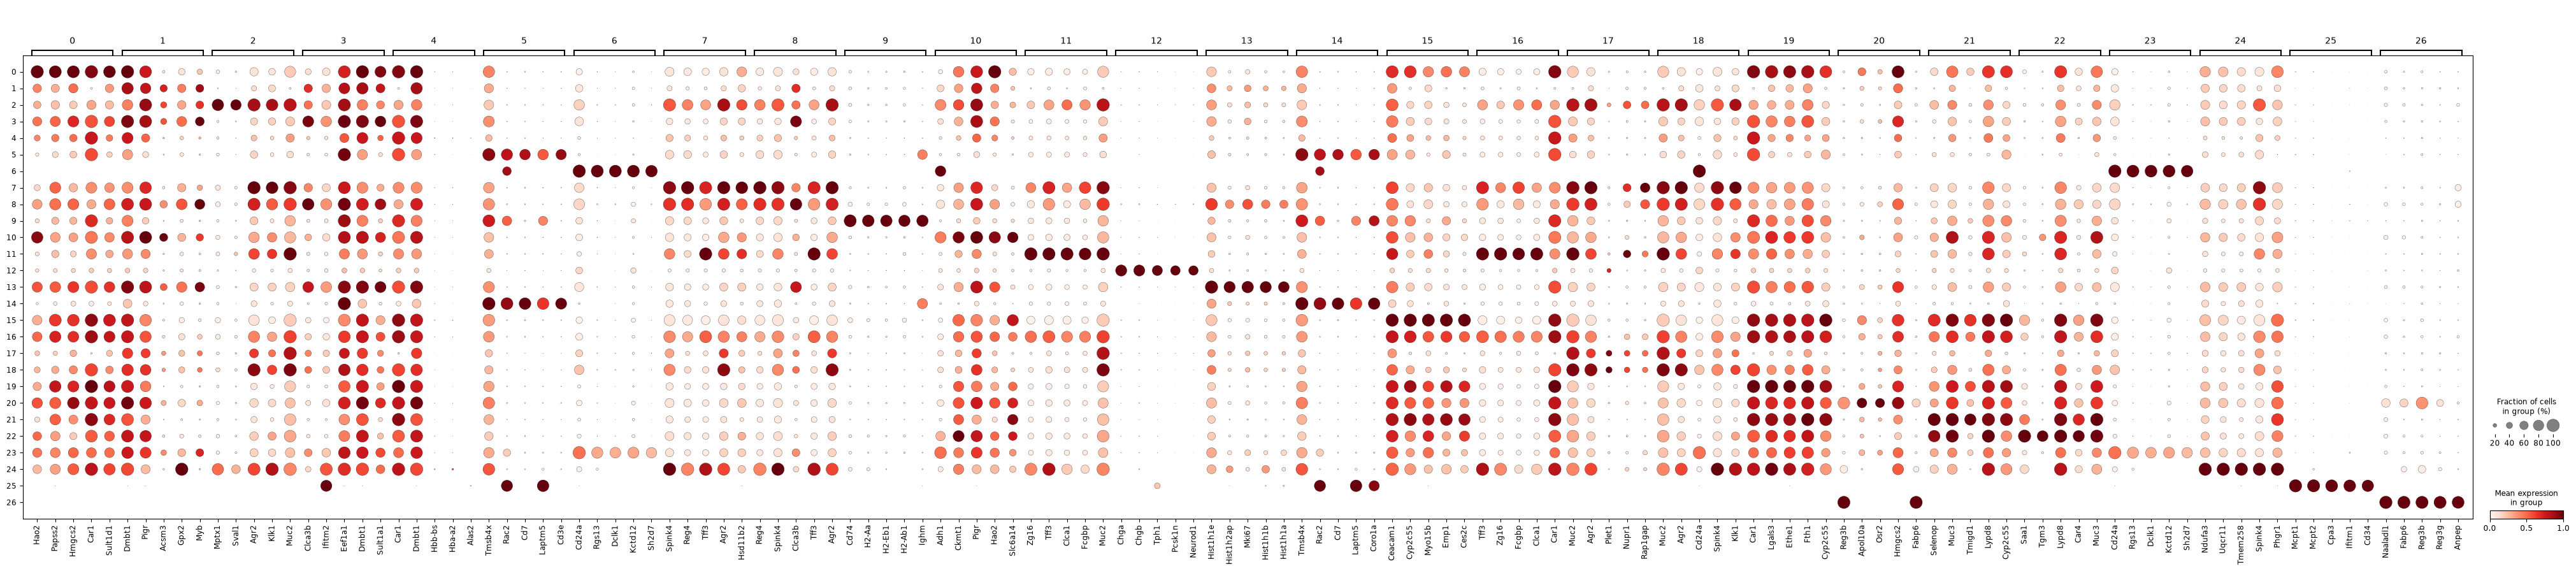

In [96]:
#plot a heatmap of given markers to assess cluster identity
use_res = "1.00"
sc.pl.heatmap(adata,markers,groupby=f"leiden_res_{use_res}",figsize=(30,8),swap_axes=True)

sc.tl.rank_genes_groups(adata, groupby=f"leiden_res_{use_res}", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(adata, groupby=f"leiden_res_{use_res}", standard_scale="var", n_genes=5,dendrogram=False)

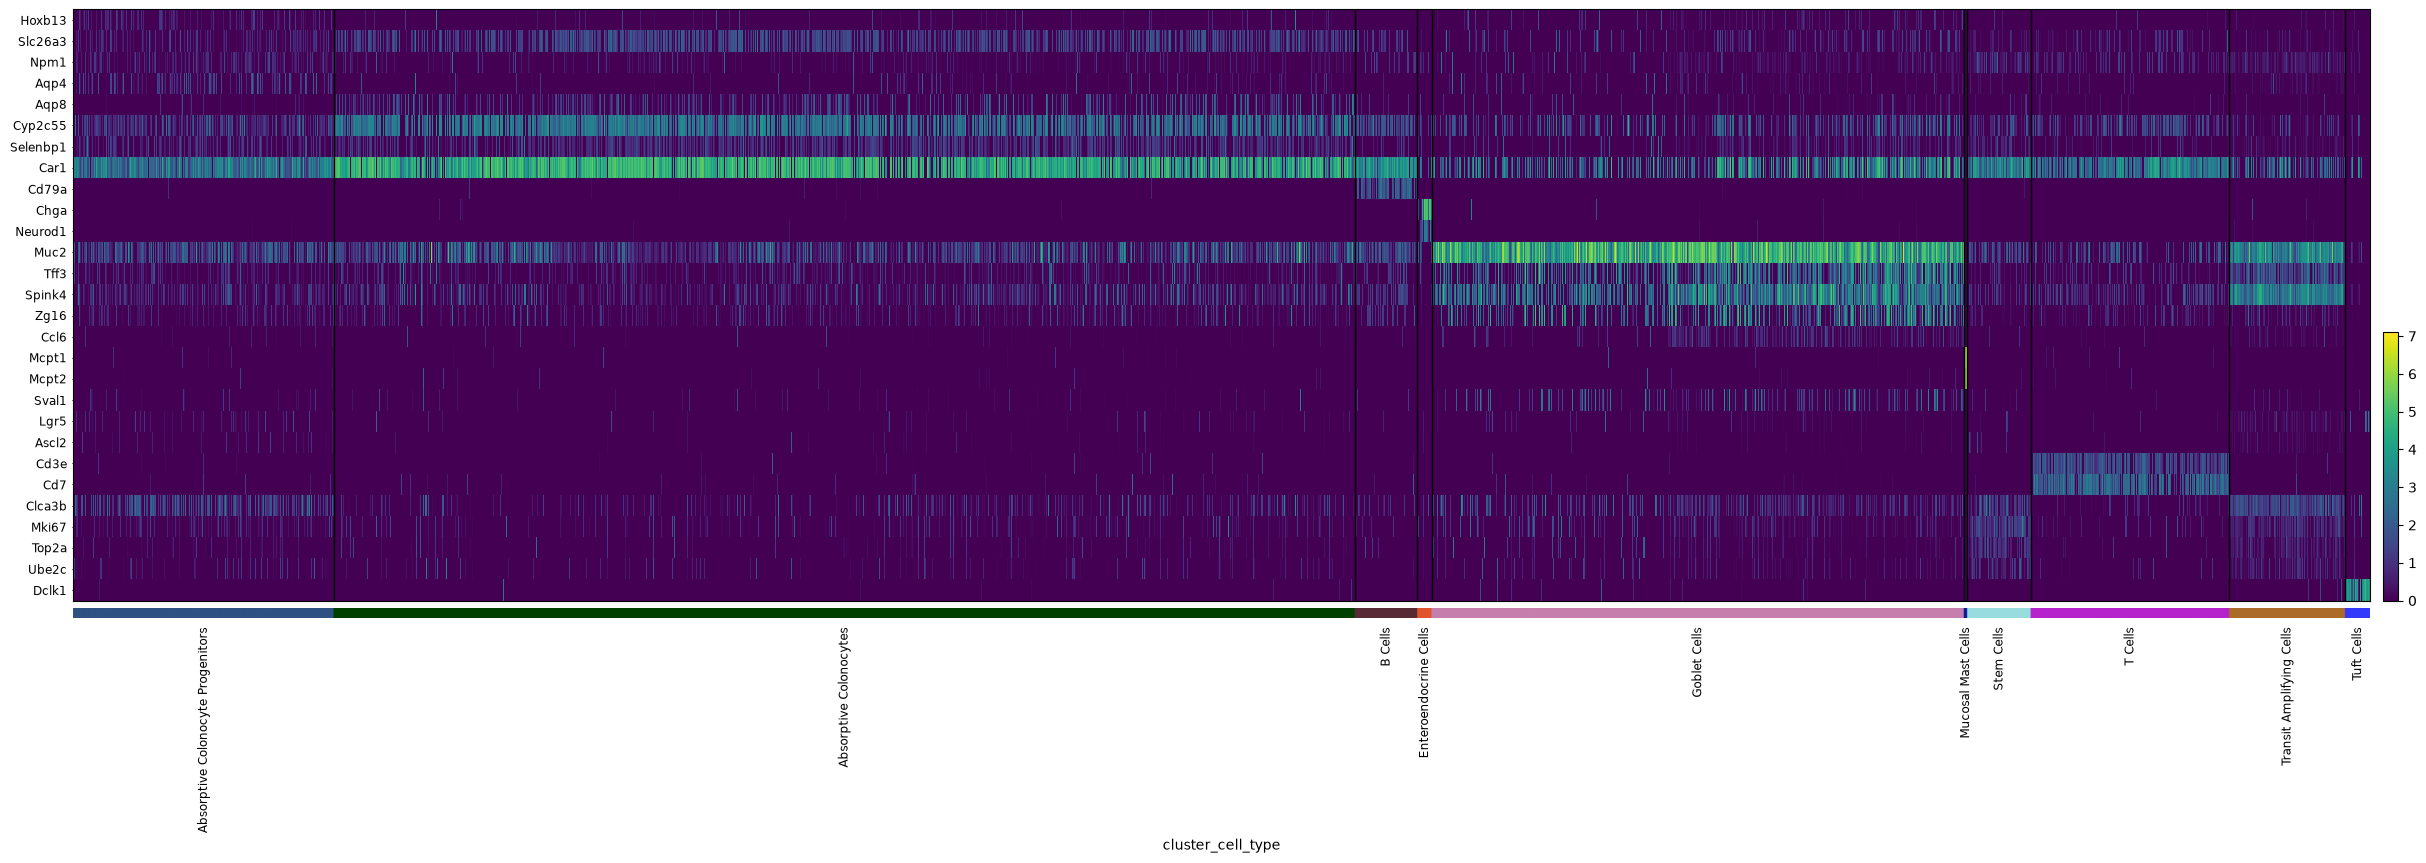

In [104]:
sc.pl.heatmap(adata,markers,groupby="cluster_cell_type",figsize=(30,8),swap_axes=True,save="diet_clustersFINAL.svg")

In [33]:
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

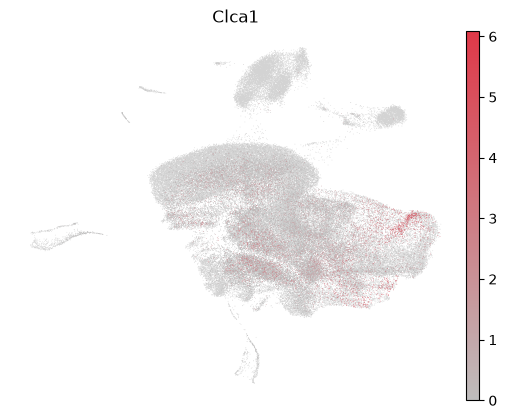

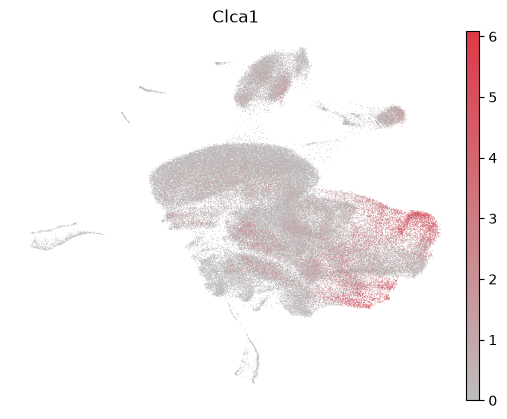

In [94]:
sc.pl.umap(adata,color=["Clca1"],mask_obs=adata.obs["treatment"] == "3DPI",cmap=ifitm_cmap,frameon=False,save="diet_clca1_3dpi_FINAL.svg")
sc.pl.umap(adata,color="Clca1",cmap=ifitm_cmap,frameon=False,save="diet_clca1_full_FINAL.svg")

In [26]:
cluster2annotation_d = {
    "0": "Absorptive Colonocytes",
    "1": "Absorptive Colonocytes",
    "2": "Goblet Cells",
    "3": "Absorptive Colonocyte Progenitors",
    "4": "Absorptive Colonocytes",
    "5": "T Cells",
    "6": "Tuft Cells",
    "7": "Goblet Cells",
    "8": "Transit Amplifying Cells",
    "9": "B Cells",
    "10": "Absorptive Colonocyte Progenitors",
    "11": "Goblet Cells",
    "12": "Enteroendocrine Cells",
    "13": "Stem Cells",
    "14": "T Cells",
    "15": "Absorptive Colonocytes",
    "16": "Goblet Cells",
    "17": "Goblet Cells",
    "18": "Goblet Cells",
    "19": "Absorptive Colonocytes",
    "20": "Absorptive Colonocytes",
    "21": "Absorptive Colonocytes",
    "22": "Absorptive Colonocytes",
    "23": "Tuft Cells",
    "24": "Goblet Cells",
    "25": "Mucosal Mast Cells",
    "26": "Absorptive Colonocytes",
}

adata.obs['cluster_cell_type'] = adata.obs["leiden_res_1.00"].map(cluster2annotation_d).astype('category')

In [41]:
#generate a DEG list of a specific cluster comparing two specific treatments
diet_clusters = adata.obs["cluster_cell_type"].cat.categories.tolist()
#live_clusters = live_redo.obs["cluster_cell_type"].cat.categories.tolist()

combined_vals = []
mhvy_only_vals = []
dhe_only_vals = []

amp_overlap = []
nf_overlap = []
total_overlap = []

with open("20260820_dietONLY_DEG_final.txt","w",encoding="utf-8") as f:
    for vclus in diet_clusters:
        print(adata[adata.obs["cluster_cell_type"] == vclus].obs["treatment"].value_counts())
        if adata[adata.obs["cluster_cell_type"] == vclus].obs["treatment"].cat.categories.tolist() != ["3DPI","amp","no_fiber"]:
            print(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
            f.write(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
        else:
            curr_diet_nf = adata[(adata.obs["treatment"].isin(["no_fiber","3DPI"])) & (adata.obs["cluster_cell_type"] == vclus)]
            curr_diet_amp = adata[(adata.obs["treatment"].isin(["amp","3DPI"])) & (adata.obs["cluster_cell_type"] == vclus)]
            sc.tl.rank_genes_groups(curr_diet_nf, groupby="treatment", method='wilcoxon',reference="no_fiber",key_added=f"diet_nf_vs_mhvy_{vclus}")
            sc.tl.rank_genes_groups(curr_diet_amp, groupby="treatment", method='wilcoxon',reference="amp",key_added=f"diet_amp_vs_mhvy_{vclus}")
            df_diet_nf = sc.get.rank_genes_groups_df(curr_diet_nf, group="3DPI",key=f"diet_nf_vs_mhvy_{vclus}")
            df_diet_amp = sc.get.rank_genes_groups_df(curr_diet_amp, group="3DPI",key=f"diet_amp_vs_mhvy_{vclus}")
        
            sig_df_diet_amp_up = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] > 0)]
            sig_df_diet_amp_dw = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] < 0)]
            sig_df_diet_nf_up = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] > 0)]
            sig_df_diet_nf_dw = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] < 0)]
        
            #diet_combined_up = sig_df_diet_nf_up.loc[(sig_df_diet_nf_up['names'].isin(sig_df_diet_amp_up['names']))]
            diet_dhe_overlap_up = sig_df_diet_nf_up.loc[(sig_df_diet_nf_up['names'].isin(sig_df_diet_amp_up['names']))]
            diet_dhe_overlap_dw = sig_df_diet_nf_dw.loc[(sig_df_diet_nf_dw['names'].isin(sig_df_diet_amp_dw['names']))]
            #diet_dhe_combined = diet_dhe_amp_overlap_up.loc[(diet_dhe_amp_overlap_up['names'].isin(diet_dhe_nf_overlap_up['names']))]
        
            # amp_nf_up_overlap = sig_df_diet_amp_up.loc[(sig_df_diet_amp_up['names'].isin(sig_df_diet_nf_up['names']))]
            # amp_nf_dw_overlap = sig_df_diet_nf_dw.loc[(sig_df_diet_nf_dw['names'].isin(sig_df_diet_amp_dw['names']))]
            # amp_nf_dhe_overlap = amp_nf_up_overlap.loc[(amp_nf_up_overlap['names'].isin(vg_dhe_up_only['names']))]
            # amp_nf_dhe_dw_overlap = amp_nf_dw_overlap.loc[(amp_nf_dw_overlap['names'].isin(vg_dhe_dw_only['names']))]
        
            f.write(f"DIET CLUSTER {vclus}:\n")
            f.write(f"Out of {len(sig_df_diet_amp_up)} total amp-up genes, {len(sig_df_diet_amp_dw)} total amp-down genes, {len(sig_df_diet_nf_up)} total no fiber-up genes, and {len(sig_df_diet_nf_dw)} total no fiber-down \n")
            # f.write(f"COMBINED UPREGULATED: {len(diet_combined_up['names'])}")
            # f.write(diet_combined_up['names'].tolist())
            #f.write(f"\n{vclus} OVERLAP UP: {len(diet_dhe_overlap_up['names'])}\n")
            #f.write(str(diet_dhe_overlap_up['names'].tolist()))
            #f.write(f"\n{vclus} OVERLAP DW: {len(diet_dhe_overlap_dw['names'])}\n")
            #f.write(str(diet_dhe_overlap_dw['names'].tolist()))
            f.write(f"\n{vclus} NO FIBER UP\n")
            f.write(str(sig_df_diet_nf_up['names'].tolist()))
            f.write(f"\n{vclus} NO FIBER DW\n")
            f.write(str(sig_df_diet_nf_dw['names'].tolist()))
            f.write(f"\n{vclus} AMP UP\n")
            f.write(str(sig_df_diet_amp_up['names'].tolist()))
            f.write(f"\n{vclus} AMP DW\n")
            f.write(str(sig_df_diet_amp_dw['names'].tolist()))
            # f.write(f"TOTAL dHE OVERLAP: {len(diet_dhe_combined['names'])}")
            # f.write(diet_dhe_combined['names'].tolist())
            # f.write(f"TOTAL AMP NF OVERLAP UP: {len(amp_nf_up_overlap['names'])}")
            # f.write(amp_nf_up_overlap['names'].tolist())
            # f.write(f"TOTAL AMP NF OVERLAP DW: {len(amp_nf_dw_overlap['names'])}")
            # f.write(amp_nf_dw_overlap['names'].tolist())
            # f.write(f"ALL DW OVERLAP: {len(amp_nf_dhe_dw_overlap['names'])}")
            # f.write(amp_nf_dhe_dw_overlap['names'].tolist())
                
    # for vclus in live_clusters:
    #     print(live_redo[live_redo.obs["cluster_cell_type"] == vclus].obs["treatment"].value_counts())
    #     if live_redo[live_redo.obs["cluster_cell_type"] == vclus].obs["treatment"].cat.categories.tolist() != ["5DPI","Mock"]:
    #         print(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
    #         f.write(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
    #     else:
    #         live_clus = live_redo[(live_redo.obs["treatment"].isin(["Mock","5DPI"])) & (live_redo.obs["cluster_cell_type"] == vclus)]
    #         sc.tl.rank_genes_groups(live_clus, groupby="treatment", method='wilcoxon',reference="Mock",key_added=f"live_{vclus}")
    #         df_live = sc.get.rank_genes_groups_df(live_clus, group="5DPI",key=f"live_{vclus}")
    #         sig_df_live_up = df_live[(df_live['pvals_adj'] < 0.05) & (df_live['logfoldchanges'] > 0)]
    #         sig_df_live_dw = df_live[(df_live['pvals_adj'] < 0.05) & (df_live['logfoldchanges'] < 0)]
        
    #         f.write(f"LIVE CLUSTER {vclus}:\n")
    #         f.write(f"\n{vclus} 5DPI UP (MOCK DW): {len(sig_df_live_up['names'])}\n")
    #         f.write(str(sig_df_live_up['names'].tolist()))
    #         f.write(f"\n{vclus} 5DPI DW (MOCK UP): {len(sig_df_live_dw['names'])}\n")
    #         f.write(str(sig_df_live_dw['names'].tolist()))
        
    # a_title = "dhe_vs_mhvy_b.csv"
    # current_clus.to_csv(a_title,index=False)

treatment
no_fiber    5577
3DPI        3700
amp         3173
Name: count, dtype: int64
treatment
amp         17735
no_fiber    17007
3DPI        14104
Name: count, dtype: int64
treatment
amp         1491
no_fiber    1433
3DPI          66
Name: count, dtype: int64
treatment
no_fiber    339
amp         224
3DPI        119
Name: count, dtype: int64
treatment
3DPI        10958
no_fiber     9502
amp          5001
Name: count, dtype: int64
treatment
no_fiber    118
amp          38
3DPI          6
Name: count, dtype: int64
treatment
no_fiber    1231
3DPI        1001
amp          803
Name: count, dtype: int64
treatment
no_fiber    7299
amp         2157
3DPI          34
Name: count, dtype: int64
treatment
no_fiber    2708
amp         1457
3DPI        1381
Name: count, dtype: int64
treatment
no_fiber    543
3DPI        328
amp         328
Name: count, dtype: int64


In [57]:
sc.tl.rank_genes_groups(adata[adata.obs["treatment"] == "no_fiber"], groupby='cluster_cell_type', method='wilcoxon')

In [45]:
all_isgs = ["ABTB2", "AC025171.1", "ADAM9", "ADAR", "AIDA", "AKR7A2", "ANKFY1", "AP3M2", "APOBEC3G", "APOL1", "APOL2", "APOL3", "APOL4", "APOL6", "ARAP2", "ARID3A", "ARID5B", "ARL4A", "ATP10A", "ATP6V0A4", "ATP6V0B", "AUTS2", "AVPR2", "B2M", "BAG1", "BAK1", "BANK1", "BATF2", "BAX", "BBC3", "BBX", "BCL2", "BCLAF1", "BPGM", "BRCA1", "BST2", "BTG1", "C1R", "C1S", "CALD1", "CALR", "CASP1", "CASP3", "CASP4", "CASP7", "CASP8", "CCDC91", "CCL2", "CCL5", "CCL7", "CCNYL1", "CCRL2", "CD164", "CD274", "CD38", "CD40", "CD47", "CD69", "CD74", "CD80", "CD86", "CDK1", "CDKN1A", "CDKN1B", "CEACAM1", "CEBPD", "CFB", "CFH", "CGAS", "CIITA", "CLIC4", "CMKLR1", "CMPK2", "CMTR1", "CNP", "COL16A1", "CSF1", "CSF2RB", "CSRP3", "CTR9", "CX3CL1", "CXCL10", "CXCL11", "CXCL9", "CYB561D2", "CYCS", "CYP24A1", "DCK", "DDIT4", "DDX1", "DDX17", "DDX21", "DDX58", "DDX60", "DHX58", "DNAJC2", "DTX3L", "E2F2", "EHD4", "EIF2AK2", "EIF2B1", "EIF3A", "EIF4E3", "ELF1", "ELK4", "EPRS1", "EPS15", "EPSTI1", "ETS2", "ETV7", "FAM111A", "FAM46A", "FAS", "FCGR1A", "FGL2", "FOSL1", "FPR1", "FUBP1", "GBP1", "GBP2", "GBP3", "GBP4", "GBP5", "GBP6", "GBP7", "GCH1", "GIMAP7", "GMFB", "GMPR", "GOLGA4", "GOLM1", "GPR18", "GZMA", "HADH", "HADHB", "HELZ2", "HERC5", "HERC6", "HIF1A", "HK2", "HLA-A", "HLA-B", "HLA-C", "HLA-DMA", "HLA-DPA1", "HLA-DQA1", "HLA-DQB1", "HLA-DRB1", "HLA-DRB3", "HLA-DRB4", "HLA-DRB5", "HLA-E", "HLA-F", "HLA-G", "HPSE", "HSD17B11", "HSH2D", "ICAM1", "IDO1", "IFI16", "IFI27", "IFI30", "IFI35", "IFI44", "IFI44L", "IFI6", "IFIH1", "IFIT1", "IFIT2", "IFIT3", "IFIT5", "IFITM1", "IFITM2", "IFITM3", "IFNAR2", "IL10RA", "IL12RB2", "IL15", "IL15RA", "IL18BP", "IL1RN", "IL23A", "IL2RB", "IL4R", "IL6", "IL7", "IQGAP1", "IRF1", "IRF2", "IRF4", "IRF5", "IRF7", "IRF8", "IRF9", "ISG15", "ISG20", "ISOC1", "ITGA2", "ITGA4", "ITGB7", "JADE2", "JAK2", "KLK3", "KLRK1", "KPTN", "LAMP3", "LAP3", "LAT", "LATS2", "LCP2", "LGALS3BP", "LGALS9", "LILRB1", "LINC01128", "LIPA", "LIPG", "LPAR6", "LRRC37A11P", "LY6E", "LYSMD2", "MAP1B", "MAP3K10", "MAP3K14", "MARCHF1", "MAX", "MB21D1", "METTL7B", "MIA3", "MLKL", "MMP25", "MOV10", "MS4A4A", "MS4A6A", "MT2A", "MTHFD2", "MVB12A", "MVP", "MX1", "MX2", "MXD4", "MYD88", "MYO1G", "NAMPT", "NAP1L1", "NCOA3", "NCOA7", "NFKB1", "NFKBIA", "NLRC5", "NMI", "NOD1", "NOS2", "NR4A3", "NT5C3A", "NUB1", "NUP93", "NUP98", "OAS1", "OAS2", "OAS3", "OASL", "OGFR", "P2RY14", "P2RY6", "PANK2", "PARP1", "PARP11", "PARP12", "PARP14", "PARP4", "PARP9", "PCGF5", "PDE4B", "PDXK", "PELI1", "PFKP", "PHB", "PHF11", "PIAS4", "PIK3AP1", "PIM1", "PLA1A", "PLA2G4A", "PLAAT4", "PLAUR", "PLOD2", "PLSCR1", "PMAIP1", "PML", "PNP", "PNPT1", "POLR2B", "PPA1", "PPM1K", "PPP3CA", "PPP5C", "PRAF2", "PRAME", "PRKCQ", "PROCR", "PSMA2", "PSMA3", "PSMB10", "PSMB2", "PSMB8", "PSMB9", "PSME1", "PSME2", "PTGS2", "PTPN1", "PTPN11", "PTPN2", "PTPN6", "PYHIN1", "RABL3", "RAC3", "RAPGEF6", "RBBP4", "RBCK1", "RBM43", "RBMX", "RFC2", "RHOC", "RIN2", "RIPK1", "RIPK2", "RNASEL", "RNF213", "RNF31", "RRP8", "RSAD2", "RTP4", "SAMD9", "SAMD9L", "SAMHD1", "SDC3", "SDCBP", "SECTM1", "SELL", "SELP", "SEM1", "SEPTIN4", "SERPING1", "SF3A1", "SKP1", "SLAMF7", "SLC15A3", "SLC25A28", "SLC39A8", "SLFN5", "SMAD4", "SMCHD1", "SOCS1", "SOCS3", "SOD2", "SP110", "SPPL2A", "SRI", "SRP9", "SRSF2", "SSBP1", "SSBP3", "SSPN", "ST3GAL5", "ST8SIA4", "STAT1", "STAT2", "STAT3", "STAT4", "SUN2", "TAP1", "TAPBP", "TDRD7", "TEAD1", "TEAD4", "TENT5A", "TIPARP", "TLK2", "TMEM106A", "TMEM140", "TMEM176A", "TNFAIP2", "TNFAIP3", "TNFAIP6", "TNFSF10", "TNIP3", "TOR1B", "TRAFD1", "TRAPPC10", "TREX1", "TRIM14", "TRIM21", "TRIM22", "TRIM25", "TRIM26", "TRIM5", "TTYH2", "TUBB", "TXNIP", "UBA7", "UBD", "UBE2D3", "UBE2L6", "UBE2Z", "UPP1", "USP18", "USP25", "VAMP5", "VAMP8", "VAT1", "VCAM1", "VCPIP1", "VEGFC", "WARS1", "XAF1", "XCL1", "XRCC6", "XRN1", "ZBP1", "ZC3HAV1", "ZCCHC2", "ZFP36L2", "ZNFX1"]
all_isgs_better = []
for isg in all_isgs:
    all_isgs_better.append(isg[0] + isg[1:].lower())
print(all_isgs_better)

['Abtb2', 'Ac025171.1', 'Adam9', 'Adar', 'Aida', 'Akr7a2', 'Ankfy1', 'Ap3m2', 'Apobec3g', 'Apol1', 'Apol2', 'Apol3', 'Apol4', 'Apol6', 'Arap2', 'Arid3a', 'Arid5b', 'Arl4a', 'Atp10a', 'Atp6v0a4', 'Atp6v0b', 'Auts2', 'Avpr2', 'B2m', 'Bag1', 'Bak1', 'Bank1', 'Batf2', 'Bax', 'Bbc3', 'Bbx', 'Bcl2', 'Bclaf1', 'Bpgm', 'Brca1', 'Bst2', 'Btg1', 'C1r', 'C1s', 'Cald1', 'Calr', 'Casp1', 'Casp3', 'Casp4', 'Casp7', 'Casp8', 'Ccdc91', 'Ccl2', 'Ccl5', 'Ccl7', 'Ccnyl1', 'Ccrl2', 'Cd164', 'Cd274', 'Cd38', 'Cd40', 'Cd47', 'Cd69', 'Cd74', 'Cd80', 'Cd86', 'Cdk1', 'Cdkn1a', 'Cdkn1b', 'Ceacam1', 'Cebpd', 'Cfb', 'Cfh', 'Cgas', 'Ciita', 'Clic4', 'Cmklr1', 'Cmpk2', 'Cmtr1', 'Cnp', 'Col16a1', 'Csf1', 'Csf2rb', 'Csrp3', 'Ctr9', 'Cx3cl1', 'Cxcl10', 'Cxcl11', 'Cxcl9', 'Cyb561d2', 'Cycs', 'Cyp24a1', 'Dck', 'Ddit4', 'Ddx1', 'Ddx17', 'Ddx21', 'Ddx58', 'Ddx60', 'Dhx58', 'Dnajc2', 'Dtx3l', 'E2f2', 'Ehd4', 'Eif2ak2', 'Eif2b1', 'Eif3a', 'Eif4e3', 'Elf1', 'Elk4', 'Eprs1', 'Eps15', 'Epsti1', 'Ets2', 'Etv7', 'Fam111a', 'Fam4

In [59]:
all_clus = adata.obs["cluster_cell_type"].cat.categories.tolist()

master_dict = {}

for clus in all_clus:
    print(f"getting clus {clus}")
    isg_dict = {}
    cluster_df = sc.get.rank_genes_groups_df(adata, group=clus)
    print(cluster_df.head())
    for isg in all_isgs_better:
        try:
            lfc_value = cluster_df.loc[cluster_df['names'] == isg, 'logfoldchanges'].values[0]
            isg_dict[isg] = lfc_value
        except IndexError as e:
            pass
            #print(f"{isg} not present")
    master_dict[clus] = isg_dict

getting clus Absorptive Colonocyte Progenitors
     names     scores  logfoldchanges  pvals  pvals_adj
0     Pigr  98.732956        1.607595    0.0        0.0
1     Car2  86.602692        1.408704    0.0        0.0
2    Fads2  85.120056        2.095120    0.0        0.0
3     Plp2  79.154694        1.575281    0.0        0.0
4  Ppp1r1b  75.785240        1.612743    0.0        0.0
getting clus Absorptive Colonocytes
     names      scores  logfoldchanges  pvals  pvals_adj
0     Car1  181.702591        2.635745    0.0        0.0
1   Lgals3  154.918671        2.121737    0.0        0.0
2    Lypd8  152.763428        2.349295    0.0        0.0
3  Cyp2c55  152.432968        2.648392    0.0        0.0
4    Ethe1  148.895660        1.916818    0.0        0.0
getting clus B Cells
    names     scores  logfoldchanges  pvals  pvals_adj
0    Cd74  89.990883        8.388704    0.0        0.0
1   H2-Aa  86.135353        8.818423    0.0        0.0
2  H2-Eb1  83.918617        8.668684    0.0        0.

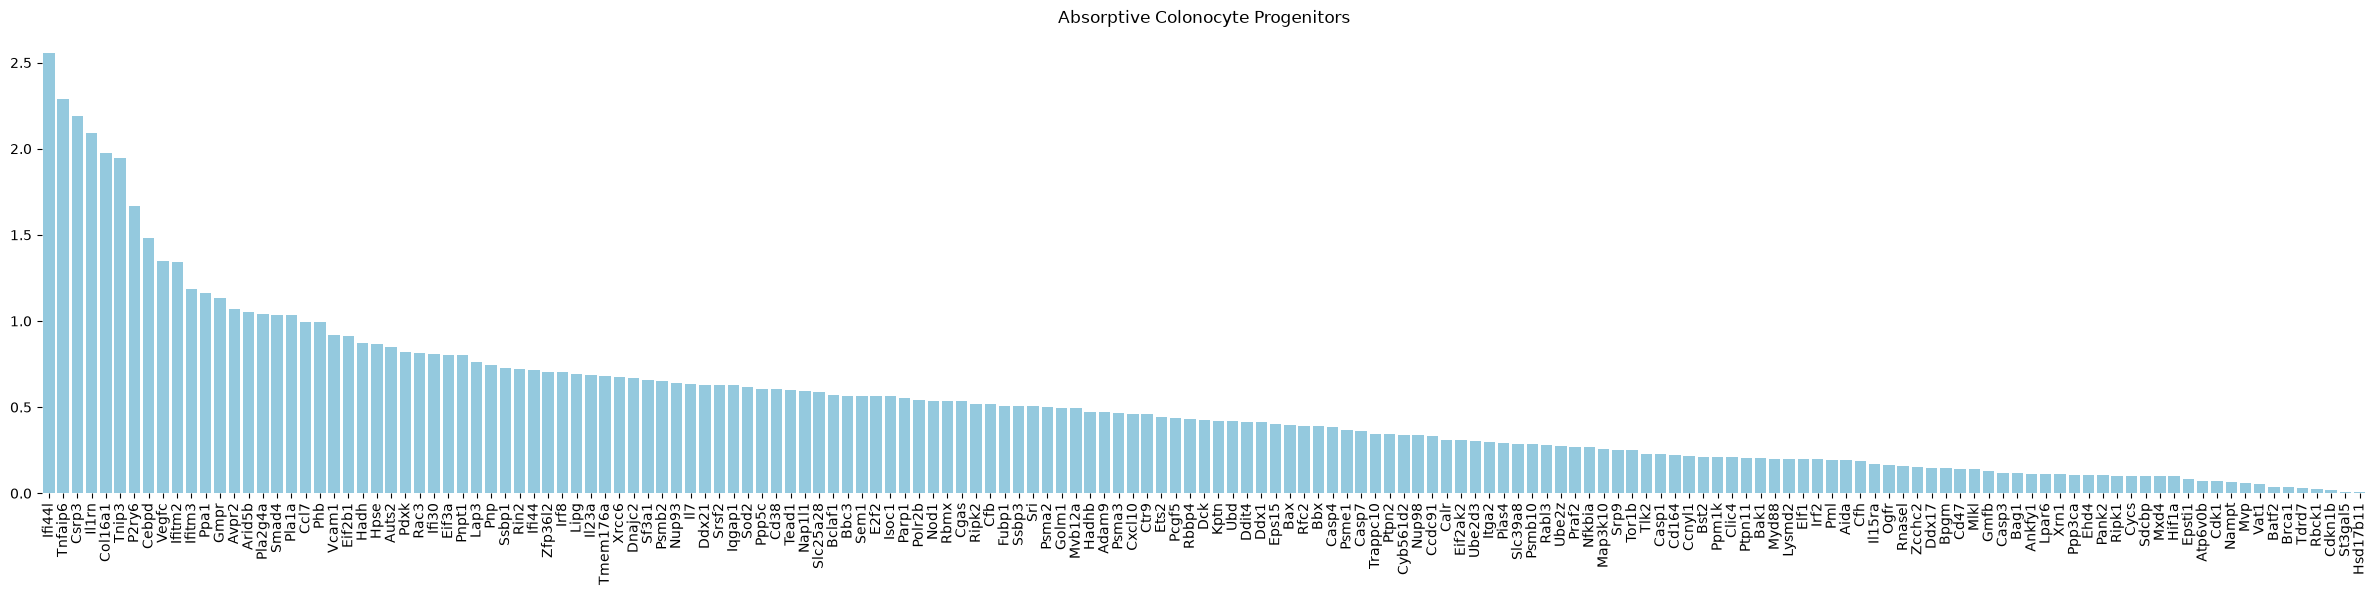

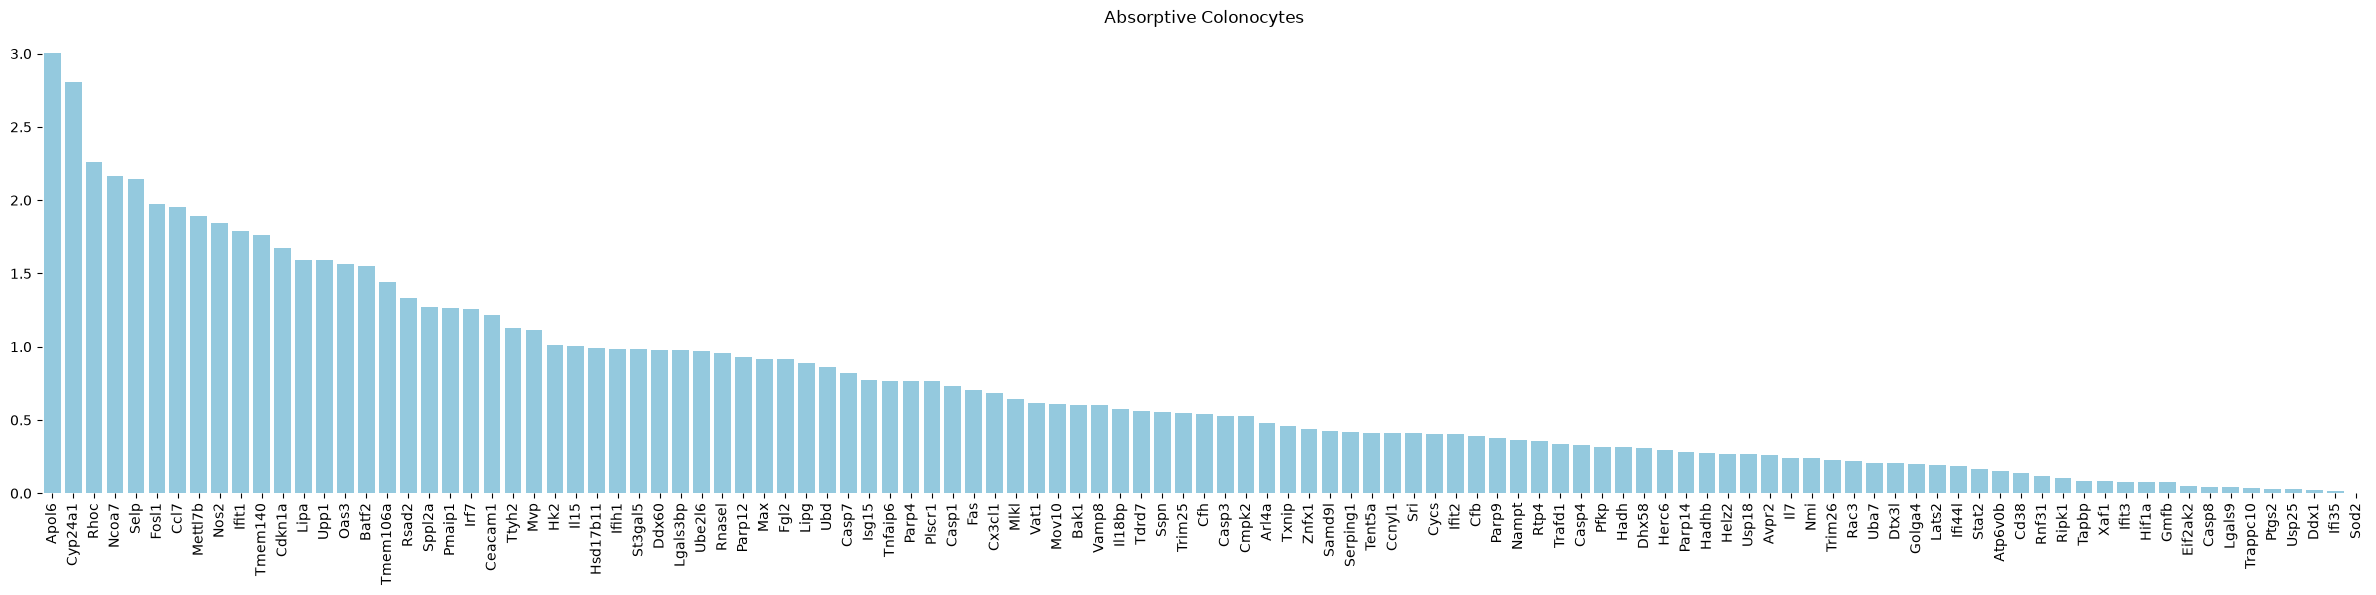

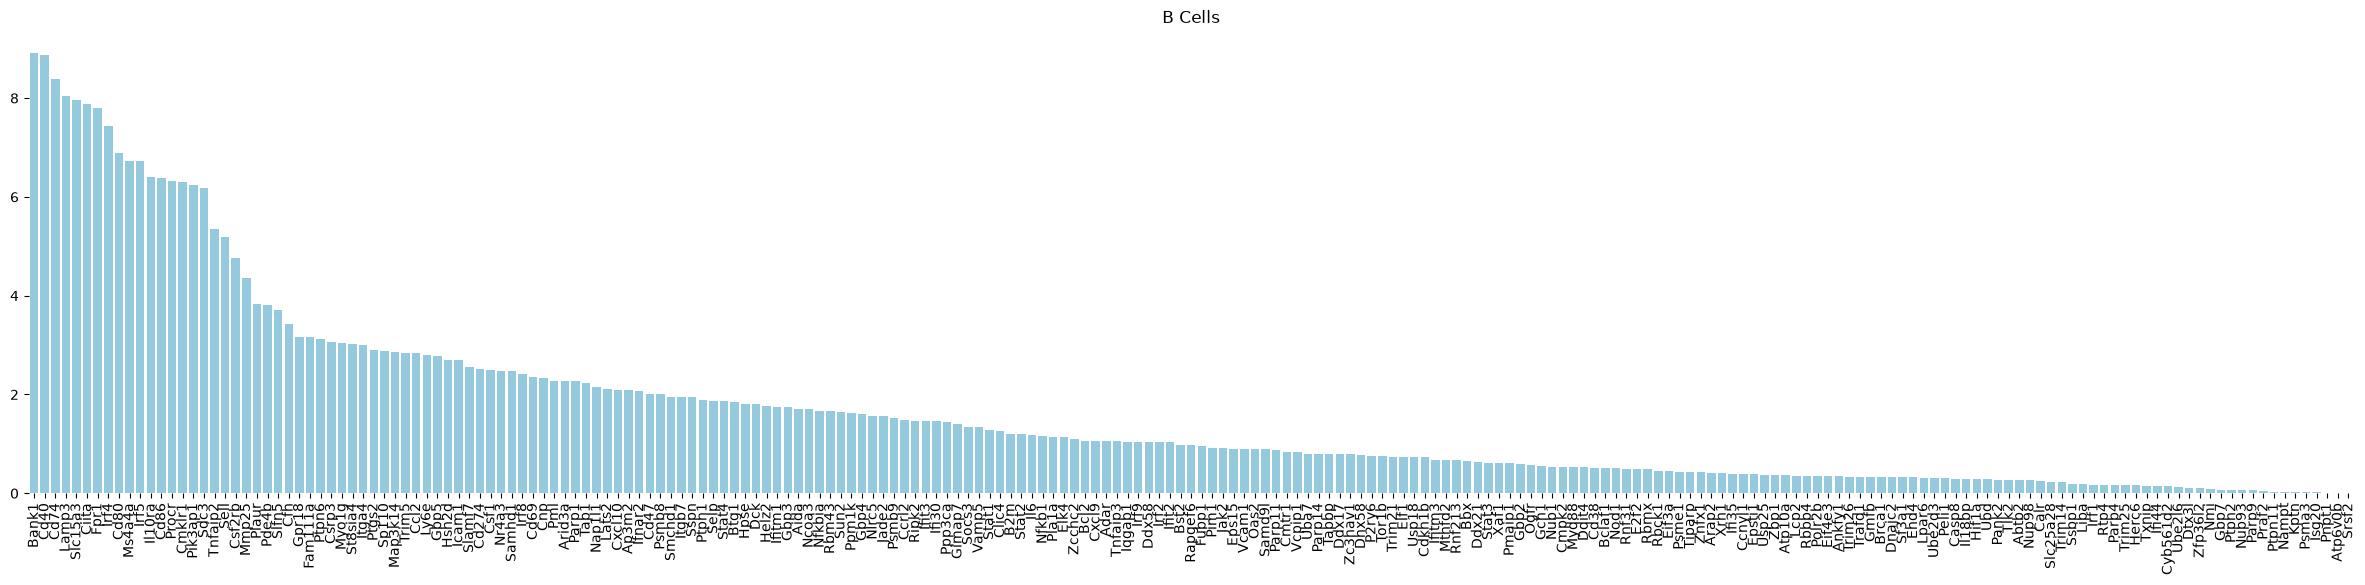

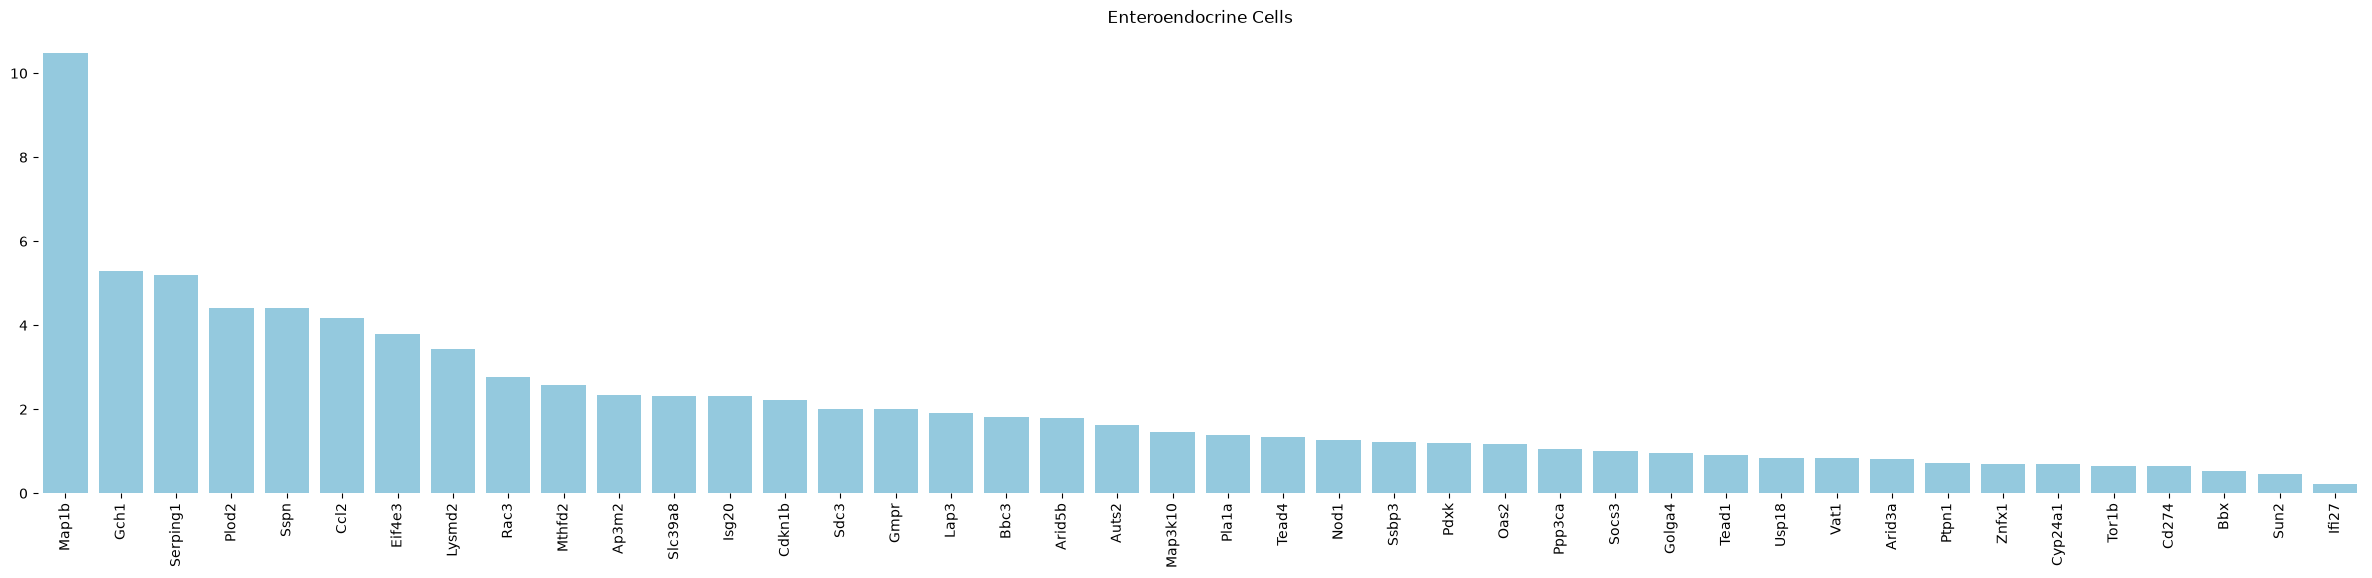

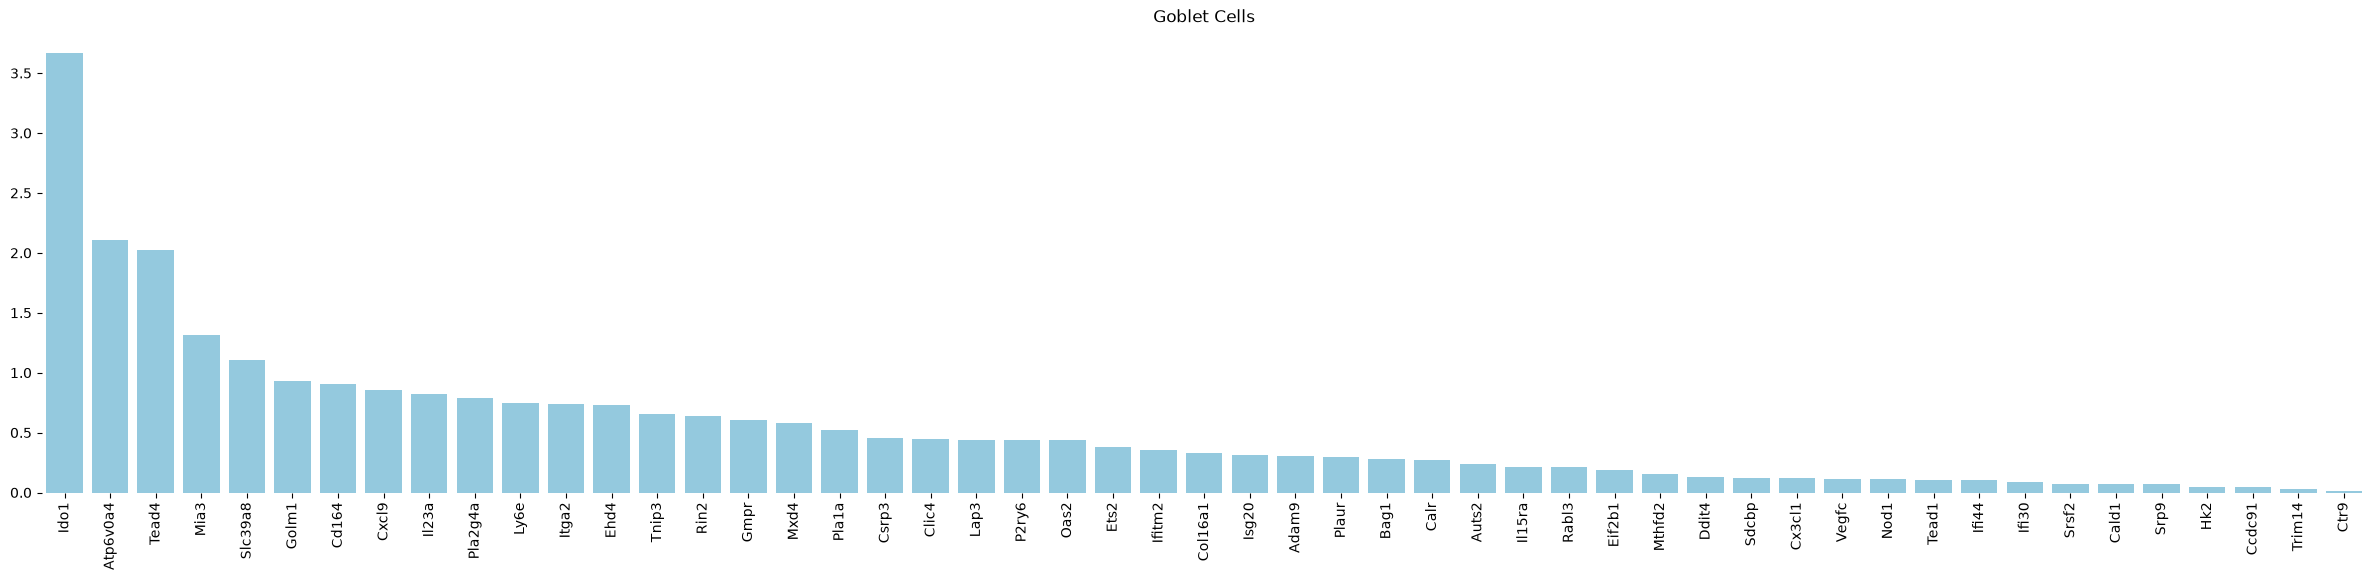

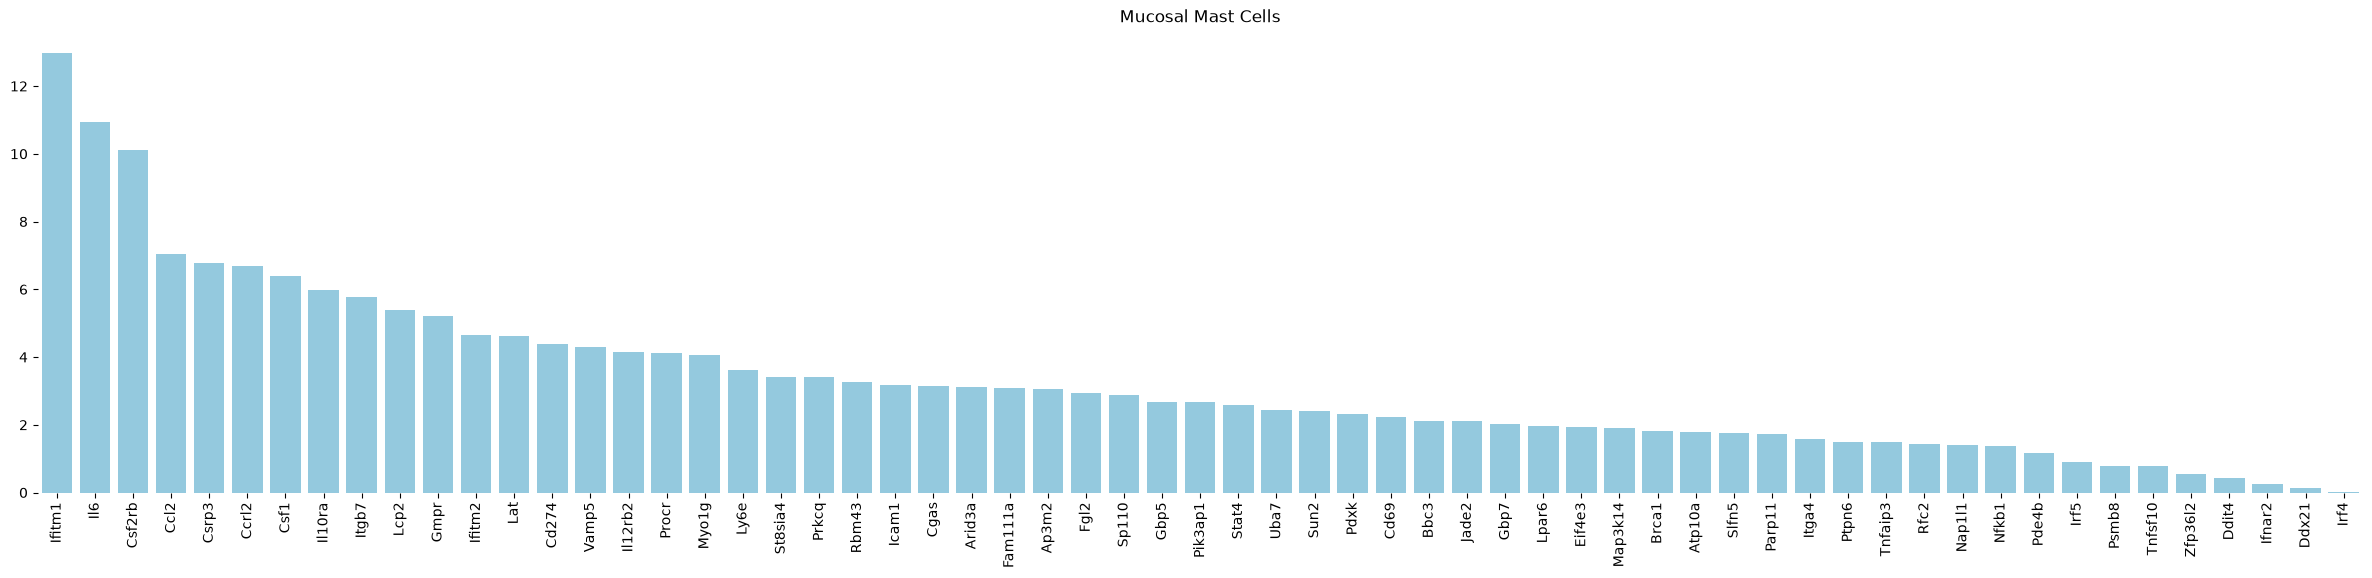

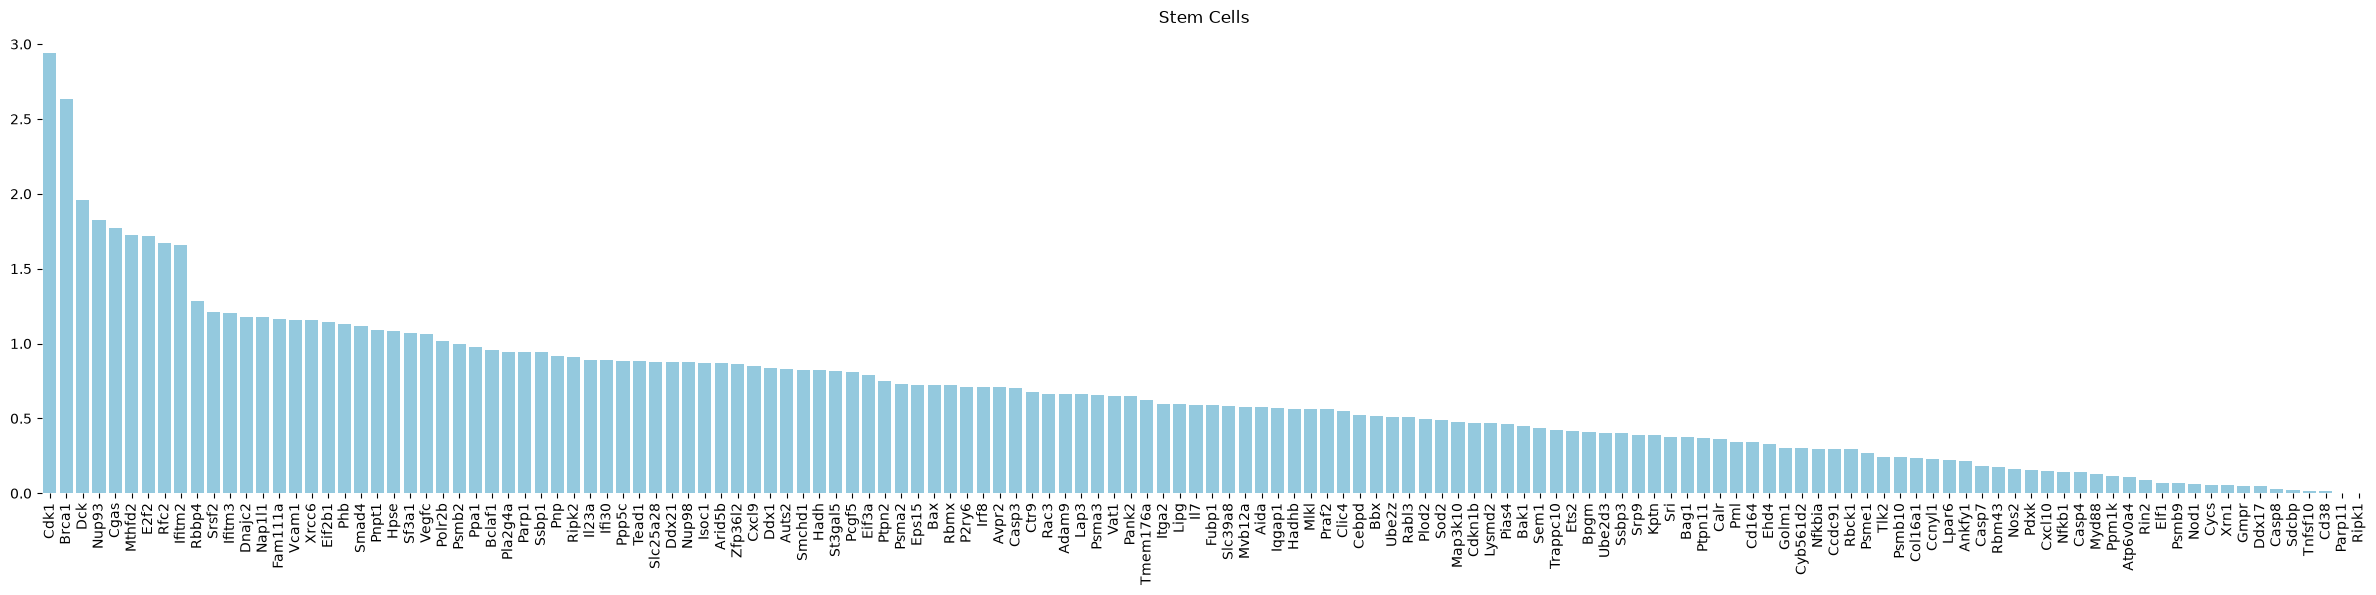

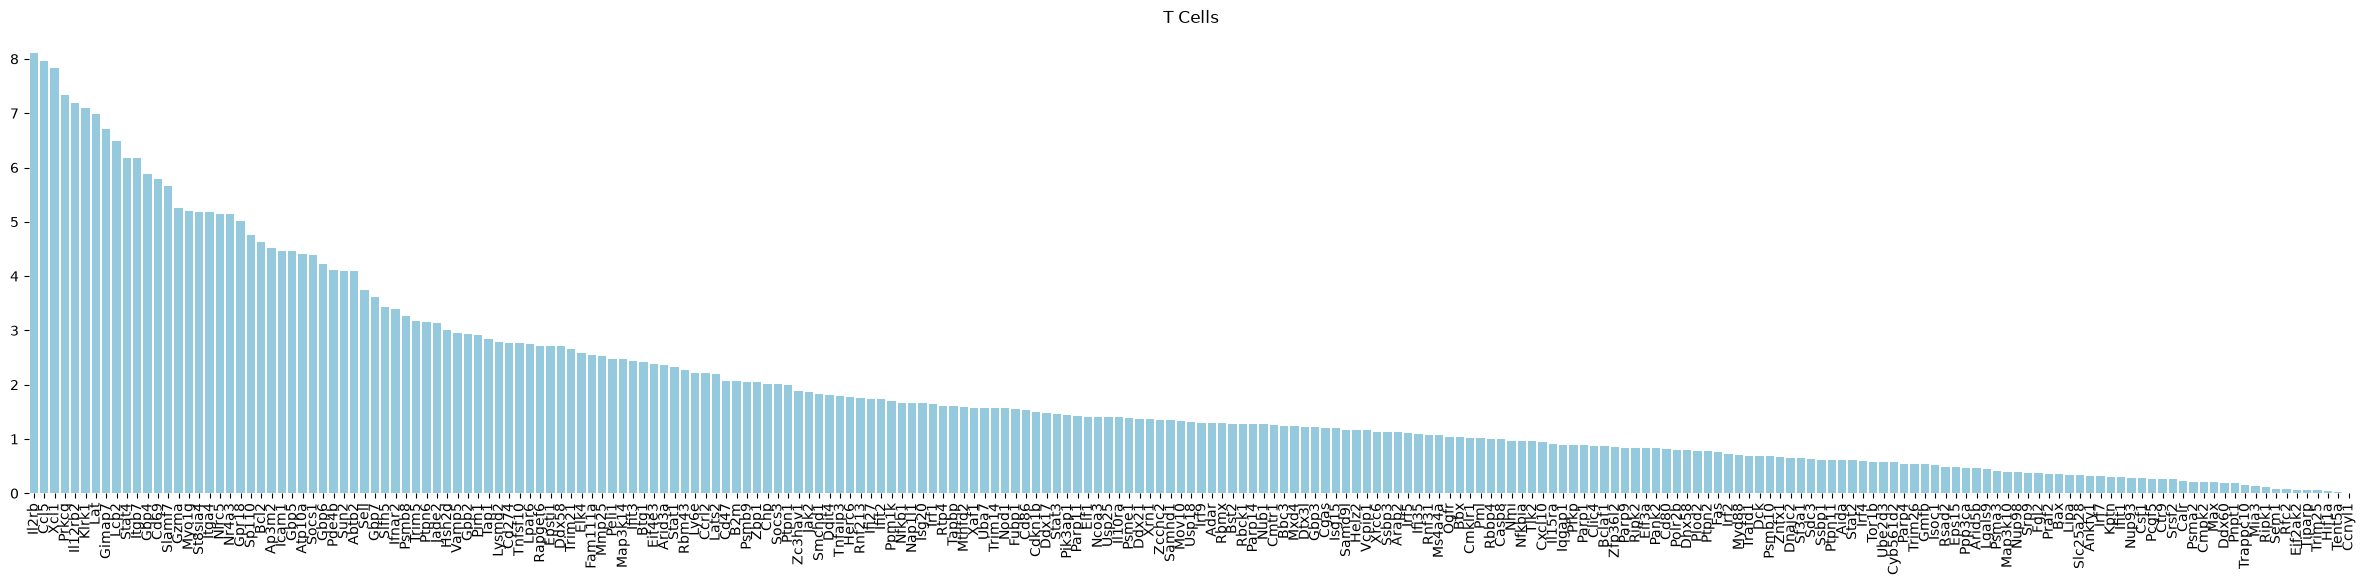

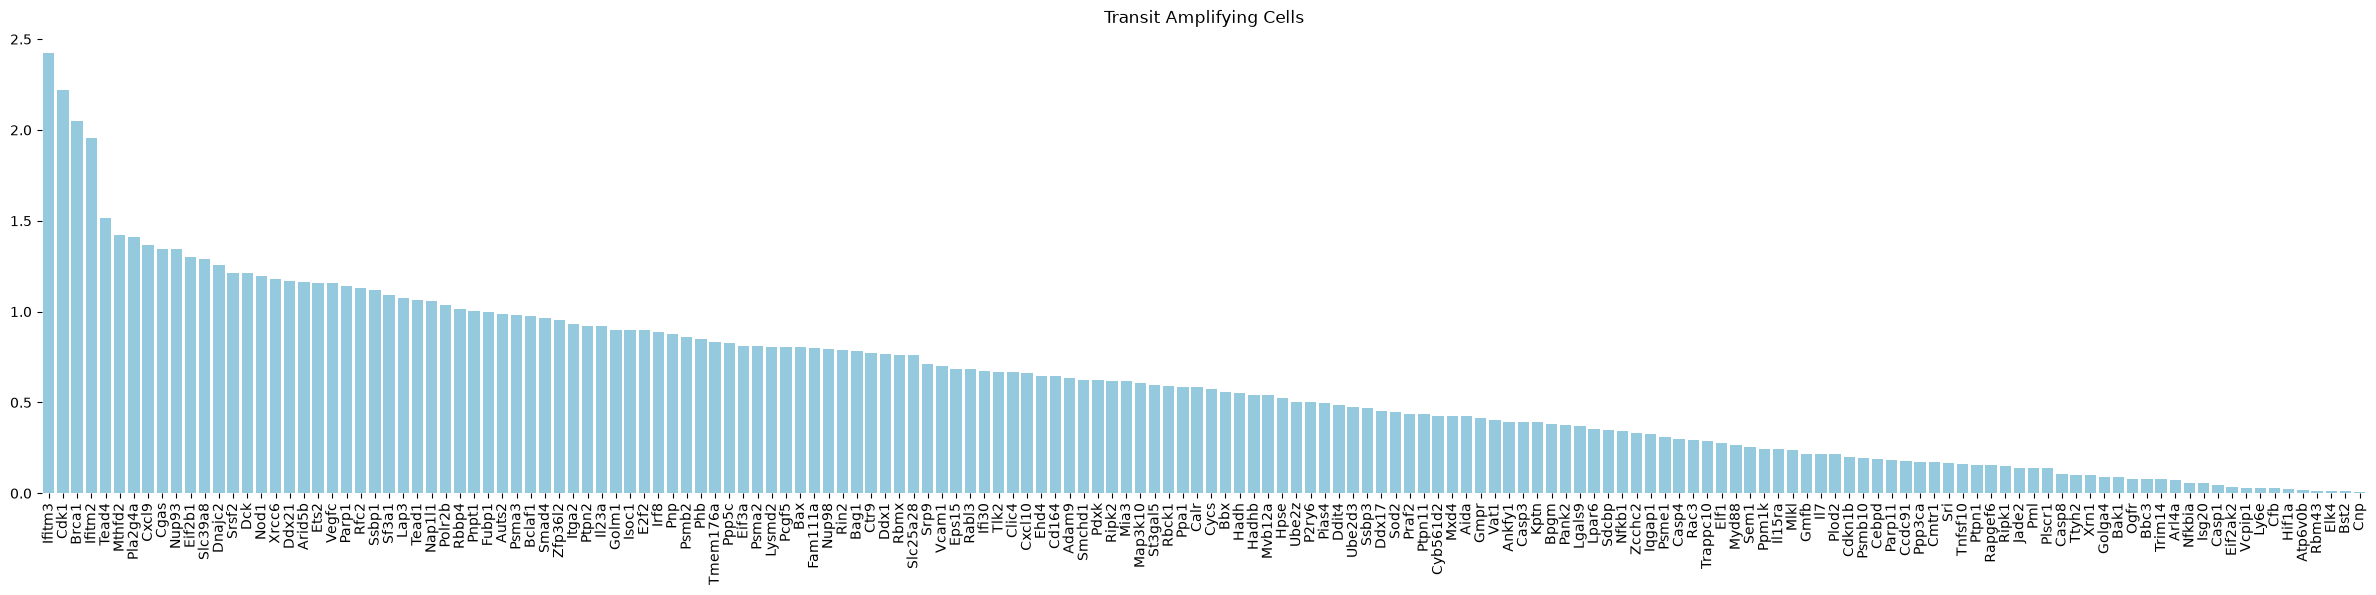

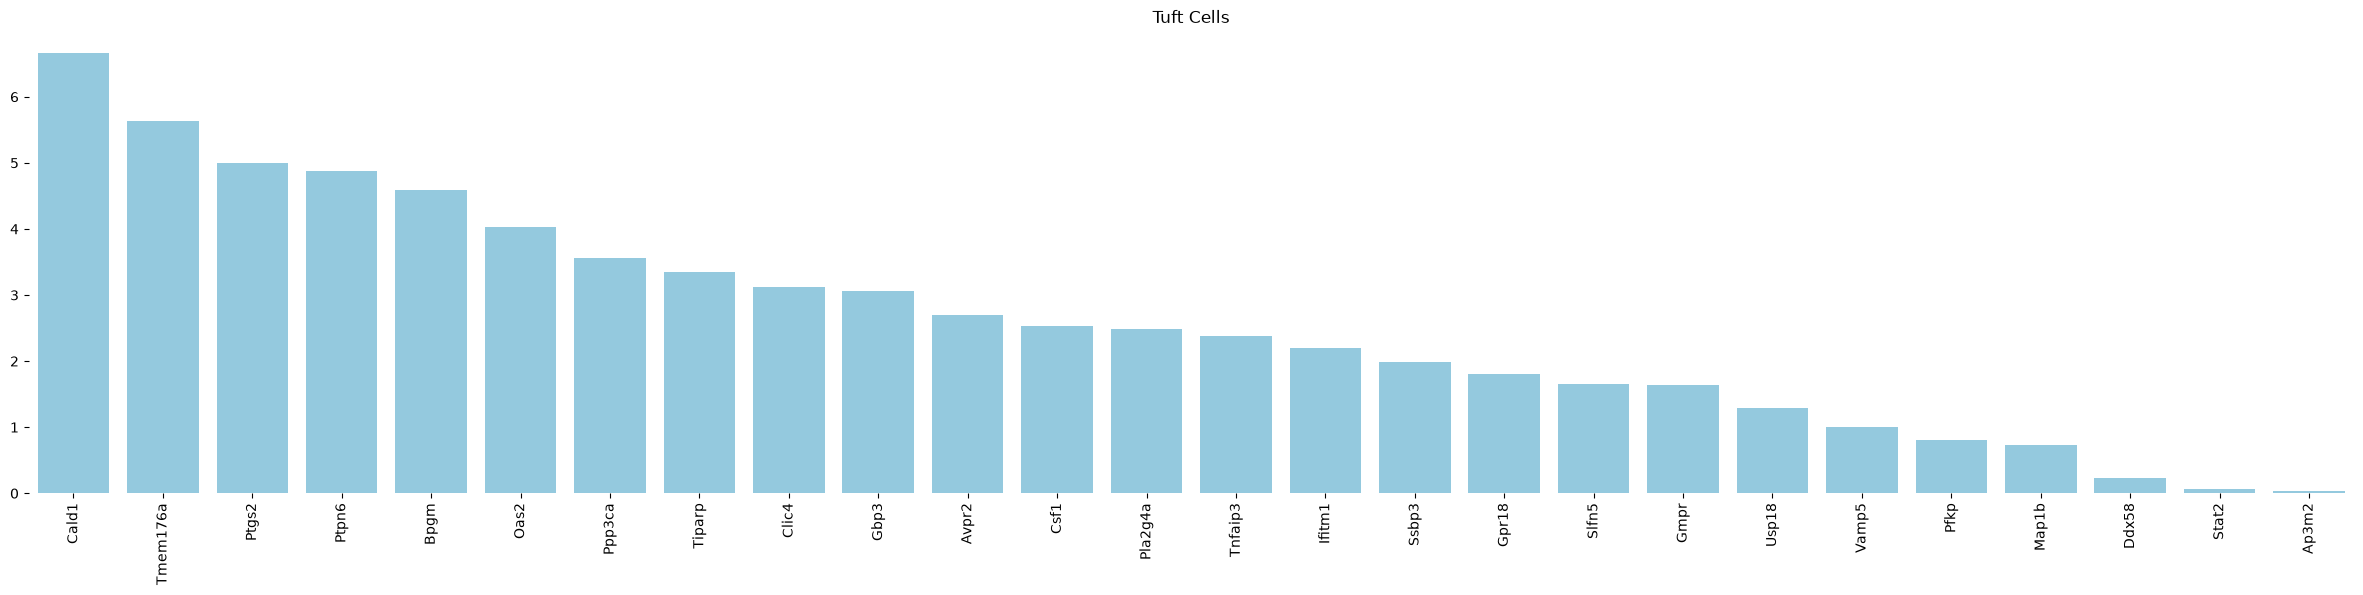

In [75]:
for clus_keys in master_dict.keys():
    final_dict = {}
    plt.figure(figsize=(30,6))
    plt.xticks(rotation=90)
    plt.title(f"{clus_keys}")
    sorted_dict = dict(sorted(master_dict[clus_keys].items(), key=lambda item: item[1],reverse=True))
    for keys, vals in sorted_dict.items():
        if vals > 0:
            final_dict[keys] = vals
    sns.barplot(final_dict,color="skyblue")
    sns.despine(top=True, right=True, left=True, bottom=True)
    plt.savefig(f"{clus_keys}_nofiber_isgs.svg",dpi=300,bbox_inches="tight")

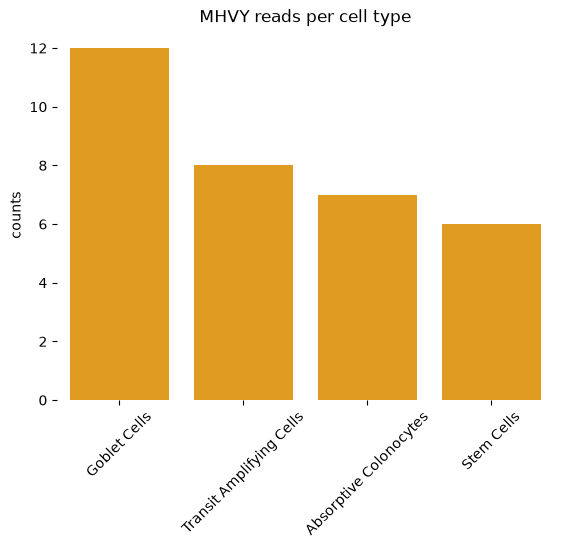

In [84]:
plt.xticks(rotation=45)
plt.title("MHVY reads per cell type")
plt.ylabel("counts")

mhvy_dict = {
    "Goblet Cells": 12,
    "Transit Amplifying Cells": 8,
    "Absorptive Colonocytes": 7,
    "Stem Cells": 6,
}
sns.despine(top=True, right=True, left=True, bottom=True)
sns.barplot(mhvy_dict,color="orange")
plt.savefig("live_mhvy_infected_cell_counts.svg",dpi=300,bbox_inches="tight")

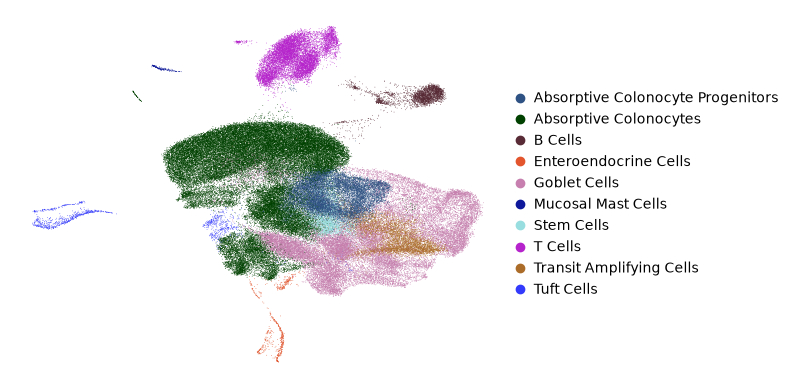

In [93]:
#sc.pl.umap(adata,color="cluster_cell_type",palette=cluster_colors,frameon=False,title="",save="dietfullFINAL.svg")

# **SEPARATING OUT CLUSTERS**

In [ ]:
#GENERATE COPIES FOR EACH INDIVIDUAL UMAP
#cd3 = adata_diet_filtered[:,'Spink4'].X

t_cell_subset = adata_filtered[
    (adata_filtered[:,'Cd3e'].X.toarray() > 0.5) &
    (adata_filtered[:,'Cd3d'].X.toarray() > 0.5) &
    (adata_filtered[:,'Cd3g'].X.toarray() > 0.5) &
    (adata_filtered[:,'Cd247'].X.toarray() > 0.5) &
    (adata_filtered[:, 'Muc2'].X.toarray() < 3)
    ].copy()

b_cell_subset = adata_filtered[
    (adata_filtered[:,'Cd19'].X.toarray() > 0.5) &
    (adata_filtered[:,'Cd79a'].X.toarray() > 0.5) &
    (adata_filtered[:,'Cldn7'].X.toarray() < 0.01) &
    (adata_filtered[:, 'Muc2'].X.toarray() < 3)
    ].copy()

epcam_subset = adata_filtered[
    (adata_filtered[:,'Epcam'].X.toarray() > 0.25) &
    (adata_filtered[:, 'Ptprc'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd79a'].X.toarray() < 0.01) &
    (adata_filtered[:, 'Cd19'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd3e'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd3d'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd3g'].X.toarray() < 0.01) &
    (adata_filtered[:,'Cd247'].X.toarray() < 0.01) &
    (adata_filtered[:,'Igha'].X.toarray() < 0.01)
].copy()
# if isinstance(cd3, (np.ndarray, list)):
#     #for dense arrays or lists
#     mask = muc.flatten() > 0
# else:
#     # For sparse matrices (e.g., csr_matrix)
#     mask = (cd3.toarray().flatten() > 0)

# adata_subset_view = adata_diet_filtered[~mask, :]

# adata_cd3_diet = adata_subset_view.copy()
#adata_cd3_diet_filteredf = adata_cd3_diet_filtered[adata_cd3_diet_filtered.obs['leiden_res_0.20'].isin(['0','1','3'])].copy()
print(t_cell_subset.shape)
print(b_cell_subset.shape)
print(epcam_subset.shape)

In [ ]:
del adata_mid_filter

In [ ]:
#COLOR DEFINITIONS
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

In [ ]:
#generate most differentially expressed genes per cluster
sc.tl.rank_genes_groups(adata_filtered, groupby="leiden_res_1.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="leiden_res_1.50", standard_scale="var", n_genes=5, save="leiden_dotplot.svg"
)

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+, #Sval1+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

#all the APC cells are also TA cells?

cluster2annotation = {
    "0": "Mitochondrial Marker",
    "1": "Colonocytes",
    "2": "Mitochondrial Marker", 
    "3": "Goblet Cell", 
    "4": "SPILLOVER", 
    "5": "Antigen Presenting Cells (APC)",
    "6": "Goblet Cell",
    "7": "Colonocytes",
    "8": "Goblet Cell",
    "9": "Colonocytes",
    "10": "Active Proliferation",
    "11": "L Cells",
    "12": "Goblet Cell Progenitor",
    "13": "Goblet Cell",
    "14": "Endothelial Cells",
    "15": "Goblet Cell Progenitor", 
    "16": "Goblet Cell", 
    "17": "Colonocytes",
    "18": "T Cells",
    "19": "Tuft Cells",
    "20": "Goblet Cell",
    "21": "Goblet Cell", 
    "22": "Colonocyte Precursor",
    "23": "Colonocytes",
    "24":"Colonocytes",
    "25":"Immune Cells",
    "26":"Stem Cells?",
    "27":"Mitochondrial Complexes",
}

In [ ]:
#print(list(adata_filtered.var_names))
print("hi")

In [ ]:
#cell count per category
print(adata_filtered.obs["i_type"].value_counts())

In [ ]:
for res in [0.5, 1.2, 1.5]:
    sc.tl.leiden(
        adata_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

In [ ]:
sc.pl.umap(
    adata_filtered,
    color=["leiden_res_0.50", "leiden_res_1.20", "leiden_res_1.50"]
)

In [ ]:
#determine which clusters have MHV positive cells in them

clusters = {}
for item in mhvy_filtered:
    try:
        mhv_cluster = adata_filtered[item].obs["leiden"].iloc[0]
    except KeyError as e:
        print(str(e) + " not in valid barcodes")
    if mhv_cluster not in clusters.keys():
        clusters[mhv_cluster] = 1
    else:
        clusters[mhv_cluster] += 1

sorted_items = sorted(clusters.items(), key=lambda item: item[0])
fnl_out = dict(sorted_items)
for keys, values in fnl_out.items():
    print(str(keys) + " " + str(values))

In [ ]:
marker_genes = {
    "Absorptive Enterocytes": ["Maf"],
    "Goblet Cell Progenitors": [],
    "Goblet Cells": ["Muc2","Tff3","Clca1"],
    "Tuft Cells": ["Dclk1"]
}

In [ ]:
#PLOT HELL

#basic format for a few things:

#BASIC PLOTS
#sc.pl.umap(adata_filtered, color=["cluster_cell_type"],frameon=False,save="clustercelltype.svg")
# sc.pl.umap(adata_filtered, color="i_type",groups=["uninfected"],frameon=False,palette=infected_colors,save="uninfected.svg")
# sc.pl.umap(adata_filtered, color="i_type",groups=["infected"],frameon=False,palette=infected_colors,save="infected.svg")
sc.pl.umap(adata_filtered, color=["leiden"], frameon=False,legend_loc="on data")
sc.pl.umap(adata_cd3_filtered, color=["leiden"], frameon=False,legend_loc="on data")

sc.pl.umap(adata_filtered, color="Foxm1",size=5,frameon=False,cmap=ifitm_cmap)
sc.pl.umap(adata_filtered, color="Ube2c",size=5,frameon=False,cmap=ifitm_cmap)

#PLOTTING GRADIENTS BASED ON SUB-CATEGORIES
# sc.pl.umap(adata_filtered, color="Muc2",mask_obs=(adata_filtered.obs.i_type=="uninfected"),frameon=False,cmap=ifitm_cmap,title="Muc2 Uninfected",save="muc2uninfected.svg")
# sc.pl.umap(adata_filtered, color="Muc2",mask_obs=(adata_filtered.obs.i_type=="infected"),frameon=False,cmap=ifitm_cmap,title="Muc2 Infected",save="muc2infected.svg")
# sc.pl.umap(adata_filtered, color="Ang4",mask_obs=(adata_filtered.obs.i_type=="uninfected"),frameon=False,cmap=ifitm_cmap,title="Ang4 Uninfected",save="ang4uninfected.svg")
# sc.pl.umap(adata_filtered, color="Ang4",mask_obs=(adata_filtered.obs.i_type=="infected"),frameon=False,cmap=ifitm_cmap,title="Ang4 Infected",save="ang4infected.svg")

#SPECIFIC GENE TEST
#sc.pl.umap(adata_filtered, color="Ptms")
#sc.pl.umap(adata_filtered, color="Aqp8")

#CLUSTER 4
sc.pl.umap(adata_filtered, color="Clca1",frameon=False,cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Ceacam1",frameon=False,cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Ang4",frameon=False,cmap=ifitm_cmap,save="Ang4.svg")
# sc.pl.umap(adata_filtered, color="Zg16",frameon=False,cmap=ifitm_cmap,save="Zg16.svg")
# sc.pl.umap(adata_filtered, color="Fcgbp",frameon=False,cmap=ifitm_cmap,save="Fcgbp.svg")

#THE LIST
sc.pl.umap(adata_filtered, color="Muc2",cmap=ifitm_cmap)
# # #sc.pl.umap(adata_filtered, color="Krt20")
sc.pl.umap(adata_filtered, color="Lrig1",cmap=ifitm_cmap,frameon=False)
sc.pl.umap(adata_filtered, color="B3galt5",cmap=ifitm_cmap,frameon=False)
#sc.pl.umap(adata_filtered, color="Mhvy",size=20,frameon=False,cmap=ifitm_cmap,save="mhvy.svg")
# sc.pl.umap(adata_filtered, color="Clca1",mask_obs=(adata_filtered.obs.i_type=="infected"),cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Clca1",mask_obs=(adata_filtered.obs.i_type=="uninfected"),cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Spink4",frameon=False,cmap=ifitm_cmap,save="spink4.svg")
# sc.pl.umap(adata_filtered, color="Clca1",frameon=False,cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Mptx1",cmap=ifitm_cmap,frameon=False,mask_obs=(adata_filtered.obs.i_type=="infected"))
# sc.pl.umap(adata_filtered, color="Mptx1",cmap=ifitm_cmap,frameon=False,mask_obs=(adata_filtered.obs.i_type=="uninfected"))
# # sc.pl.umap(adata_filtered, color="Spdef",frameon=False,cmap=ifitm_cmap,save="spdef.svg")
# # #sc.pl.umap(adata, color="IGJ", mask_obs=(adata.obs.bulk_labels == "CD19+ B"), size=20)
# #sc.pl.umap(adata_filtered, color="Ifit", mask_obs=(adata_filtered.obs.i_type == "infected"),cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Epcam",cmap=ifitm_cmap,na_color="white",frameon=False)
# #sc.pl.umap(adata_filtered, color="Cd45",cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Ifitm2",cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Ifitm3",cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Ifitm1",cmap=ifitm_cmap,na_color="white",frameon=False)
# # sc.pl.umap(adata_filtered, color="Ifitm2", mask_obs=(adata_filtered.obs.i_type == "uninfected"),cmap=ifitm_cmap,na_color="white",frameon=False)
# # sc.pl.umap(adata_filtered, color="Ifitm3", mask_obs=(adata_filtered.obs.i_type == "uninfected"),cmap=ifitm_cmap,na_color="white",frameon=False)
# # sc.pl.umap(adata_filtered, color="Ifitm2")
# # sc.pl.umap(adata_filtered, color="Ifitm3")
# sc.pl.umap(adata_filtered, color="Olfm4")
# sc.pl.umap(adata_filtered, color="Best2") #no Best4 or OTOP

# #COLONOCYTES
# sc.pl.umap(adata_filtered, color="Slc12a2",cmap=ifitm_cmap,frameon=False)
# #sc.pl.umap(adata_filtered, color="Krt20")

# # # sc.pl.umap(adata_filtered, color="Ifit2")

# sc.pl.umap(adata_filtered, color="Ifit1")
# # sc.pl.umap(adata_filtered, color="Ifit3")
# sc.pl.umap(adata_filtered, color="Mx2")

# #sc.pl.umap(adata_filtered, color="Muc2")
# sc.pl.umap(adata_filtered, color="Defb29")
# #sc.pl.umap(adata_filtered, color="Epcam")
# sc.pl.umap(adata_filtered, color="Chga")
# # #Muc2, Dclk, Lyz14, Epcam1, Chga

# #TUFT CELLS
#sc.pl.umap(adata_filtered, color="Dclk1",cmap=ifitm_cmap,frameon=False,save="dclk1.svg")

#adata_filtered.obs

#Figure out number of cluster 4 cells in Muc2 expression between 3 and 7


In [ ]:
adata_filtered.var

In [ ]:
adata_filtered.obs['cluster_cell_type'] = adata_filtered.obs["leiden"].map(cluster2annotation).astype('category')

In [ ]:
sc.tl.rank_genes_groups(adata_filtered, groupby="i_type", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="cluster_cell_type", standard_scale="var", n_genes=5, save="i_type_cluster_dotplot.svg"
)

In [ ]:
#cluster counts
total_clusters = 22
all_uninfected = []
all_infected = []

for i in range(0, total_clusters):  
    subset_in = adata_filtered[(adata_filtered.obs["leiden"] == str(i)) & (adata_filtered.obs["i_type"] == "infected")].shape[0]
    subset_un = adata_filtered[(adata_filtered.obs["leiden"] == str(i)) & (adata_filtered.obs["i_type"] == "uninfected")].shape[0]
    total = subset_un + subset_in
    print("total: " + str(total))
    #my_clusters[i] = [round(subset_un/total, 2), round(subset_in/total, 2)]
    all_uninfected.append(round(subset_un/total, 2))
    all_infected.append(round(subset_in/total, 2))

print(len(all_uninfected))
print(len(all_infected))

data = {
    "Cluster": list(range(0,22)),
    "Uninfected": all_uninfected,
    "Infected": all_infected
}

df = pd.DataFrame(data)

# for keys, values in my_clusters.items():
#     print(str(keys) + ": " + str(values))

In [ ]:
df_pivot = df.pivot_table(index='Cluster', values=['Uninfected','Infected'], aggfunc='sum')

print(df_pivot)

# Set Seaborn style
sns.set_theme()
colors = ["red","blue"]

# Plot using Pandas with stacked=True
df_pivot.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Uninfected vs Infected Proportions')
plt.ylabel('Percentage of Cluster')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Ranking genes by infection then graphing by cluster cell type
sc.tl.rank_genes_groups(adata_filtered, groupby="i_type", method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="cluster_cell_type", standard_scale="var", n_genes=5, save="i_type_dotplot.svg"
)

In [ ]:
#making this a loop so it isn't stupid

num_clusters = 25

for i in range(0, num_clusters):
    curr_cluster = adata_filtered[(adata_filtered.obs["leiden_res_1.50"] == str(i))].copy()
    sc.tl.rank_genes_groups(curr_cluster, groupby='i_type', reference='uninfected', method='wilcoxon',key_added='i_type_compare')
    current_clus = sc.get.rank_genes_groups_df(curr_cluster, group="infected",key='i_type_compare')
    title = "comp_cluster_1.50_" + str(i) + ".csv"
    current_clus.to_csv(title,index=False)

In [ ]:
#second loop for items in cell clusters
adata_filtered

In [ ]:
sc.pl.rank_genes_groups_dotplot(clus_zero, groupby='i_type', n_genes=10, key='i_type_compare') 
#sc.pl.rank_genes_groups_dotplot(adata_filtered, groupby='leiden', n_genes=10, key='diff_expr_4_2') 

In [ ]:
cluster_four = adata_filtered[(adata_filtered.obs["leiden_"] == "4")].copy()
print(cluster_four.obs)
print(adata_filtered.obs.value_counts)

In [ ]:
#code graveyard

#determine gene presences in MHV positive cells
#TEST: AAAGCCAGTTCCAGAT
all_genes = {}
#test = "AAAGCCAGTTCCAGAT"
all_gene_names = adata_filtered.var_names
# for item in mhvy_filtered.obs_names:
#     mhv_cluster = adata_filtered[item, :]
#     if mhv_cluster not in clusters.keys():
#         clusters[mhv_cluster] = 1
#     else:
#         clusters[mhv_cluster] += 1
for name in all_gene_names:
    all_genes[name] = []

gene_list = []
for barcode in mhvy_filtered.obs_names:
# gene_list = []
# print("checking " + barcode)
    try:
        if adata_filtered[barcode,"Muc2"].X[0,0] > 0:
            gene_list.append(barcode)
    except KeyError as e:
        print(str(e) + " not valid")

len(gene_list)
#len(mhvy_filtered.obs_names)

#find percentage of clusters
my_four_counts = {}
total_cells = 3251
labels = []
values = []
for s_type in list(set(adata_filtered.obs["sample"])):
    my_four_counts[s_type] = 0

for item in cluster_four.obs["sample"]:
    my_four_counts[item] += 1

for key in my_four_counts.keys():
    percent_val = my_four_counts[key] / total_cells
    labels.append(key)
    values.append(percent_val)

print(labels)
print(values)

fig,ax = plt.subplots()

ax.bar(labels, values, label=labels)

ax.set_ylabel('% of cells in cluster 4')
ax.set_title('Cluster 4 Populations')
plt.xticks(rotation=90)
plt.savefig("cluster_4_pops.svg", dpi=300)


In [ ]:
#STEP 6: LOAD COLOR PALETTES
infected_colors = {
    "5DPI": "#e88048",
    "Mock": "#582B36"
}

cluster_colors = ["#2E52A3",
                  "#004100",
                  "#582B36",
                  "#E2552D",
                  "#009499",
                  "#E3BD33",
                  "#09094A",
                  "#C67FAE",
                  "#A6BE47",
                  "#BAA5FF",
                  "#FDD5A1",
                  ]

extra_cluster_colors = ["#6D5698",
                        "#98DDDF",
                        "#A00239"
                       ]

extra_extra_cluster_colors = [
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  
                  "#F53C9F",
                  "#B623CC",
                  "#D7E8BC",
                  "#BAA5FF",
]

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
dp_hex = ["#FFFFFF","#0075B8"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)
dp_cmap = mcolors.LinearSegmentedColormap.from_list("dp_cmap",dp_hex)

In [ ]:
sc.pp.pca(epcam_subset)
sc.pl.pca_variance_ratio(epcam_subset)

In [ ]:
# Get PCs from the AnnData object
pcs = epcam_subset.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, epcam_subset.obs, "sample")

print("finished harmony")

# Store corrected PCs back in the AnnData object
epcam_subset.obsm['X_pca_harmony'] = harmony_out.Z_corr
sc.pp.neighbors(epcam_subset, use_rep='X_pca_harmony')
sc.tl.umap(epcam_subset)

In [ ]:
sc.pp.neighbors(epcam_subset, use_rep='X_pca_harmony')
sc.tl.umap(epcam_subset)

In [ ]:
sc.pl.umap(epcam_subset, color="condition")

In [ ]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(epcam_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    epcam_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)
sc.pl.umap(
    epcam_subset,
    color="condition"
)

In [ ]:
#plot a heatmap of given markers to assess cluster identity
markers = ["Ifitm2","Slc26a3", "Npm1", "Aqp4", "Aqp8", "Cyp2c55", "Selenbp1", "Car1", "B3galt5", "Chga", "Neurod1", "Muc2", "Tff3", "Spink4", "Zg16", "Ccl6", "Sval1", "Lgr5", "Ascl2", "Pclaf", "Clca3b","Mki67", "Top2a", "Ube2c", "Dclk1"]

sc.pl.heatmap(epcam_subset,markers,groupby="leiden_res_0.75",figsize=(30,8),swap_axes=True)

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(epcam_subset, groupby="leiden_res_0.75", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    epcam_subset, groupby="leiden_res_0.75", standard_scale="var", n_genes=5, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+, #Sval1+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

#all the APC cells are also TA cells?

cluster2annotation = {
    "0": "Mitochondrial Marker",
    "1": "Colonocytes",
    "2": "Mitochondrial Marker", 
    "3": "Goblet Cell", 
    "4": "SPILLOVER", 
    "5": "Antigen Presenting Cells (APC)",
    "6": "Goblet Cell",
    "7": "Colonocytes",
    "8": "Goblet Cell",
    "9": "Colonocytes",
    "10": "Active Proliferation",
    "11": "L Cells",
    "12": "Goblet Cell Progenitor",
    "13": "Goblet Cell",
    "14": "Endothelial Cells",
    "15": "Goblet Cell Progenitor", 
    "16": "Goblet Cell", 
    "17": "Colonocytes",
    "18": "T Cells",
    "19": "Tuft Cells",
    "20": "Goblet Cell",
    "21": "Goblet Cell", 
    "22": "Colonocyte Precursor",
    "23": "Colonocytes",
    "24":"Colonocytes",
    "25":"Immune Cells",
    "26":"Stem Cells?",
    "27":"Mitochondrial Complexes",
}

In [ ]:
#adata = ad.concat(adatas, label="sample")
#adata.obs_names_make_unique()

# for sample_id, filename in raw_samples.items():
#     sample_adata = sc.read_10x_h5(filename)
#     #sample_adata = sc.read_10x_mtx(filename,compressed=True)
#     sample_adata.var_names_make_unique()
#     adatas_raw[sample_id] = sample_adata

# adata_raw = ad.concat(adatas_raw, label="sample")
# adata_raw.obs_names_make_unique()

### THIS IS FOR SINGLE-LOOP ANALYSIS, DO NOT USE IF DOING PER-SAMPLE ANALYSIS ###

if experiment == "dHE":
    adata.obs["condition"] = "Mock"
    #adata_raw.obs["condition"] = "Mock"
    
    for i in range(1,16):
        match i:
            case val if 6<=int(val)<=10:
                adata.obs.loc[adata.obs["sample"] == f"sample_{i}", "condition"] = "dHE"
                #adata_raw.obs.loc[adata_raw.obs["sample"] == f"sample_{i}", "condition"] = "dHE"
            case val if 11<=int(val)<=15:
                adata.obs.loc[adata.obs["sample"] == f"sample_{i}", "condition"] = "MHVY"
                #adata_raw.obs.loc[adata_raw.obs["sample"] == f"sample_{i}", "condition"] = "MHVY"
                
elif experiment == "fiber":
    adata.obs["treatment"] = "Mock"
    adata_raw.obs["treatment"] = "Mock"
    
    for i in range(1,16):
        match i:
            case val if 1<=int(val)<=5:
                adata.obs.loc[adata.obs["sample"] == f"sample_{i}", "treatment"] = "no_fiber"
                adata_raw.obs.loc[adata_raw.obs["sample"] == f"sample_{i}", "treatment"] = "no_fiber"
            case val if 6<=int(val)<=10:
                adata.obs.loc[adata.obs["sample"] == f"sample_{i}", "treatment"] = "amp"
                adata_raw.obs.loc[adata_raw.obs["sample"] == f"sample_{i}", "treatment"] = "amp"
else:
    print("ERROR! no valid experiment selected")

print("OLD SHAPES")
print(adata.shape)
#print(adata_raw.shape)

#trim the genes down from the raw data to match the filtered data
#if int(adata.n_vars) != int(adata_raw.n_vars):
#    adata_raw = adata_raw[: , adata.var_names].copy()

#Display our AnnData object sizes
print("NEW SHAPES")
print(adata.shape)
#print(adata_raw.shape)

print(adatas["sample_1"].obs["leiden_res_0.75"].cat.categories.tolist())
